In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from matplotlib.lines import Line2D
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, GridSearchCV

# Para k-modas se requiere el paquete 'kmodes' (instalar una sola vez):
import sys
!{sys.executable} -m pip install kmodes
from kmodes.kmodes import KModes

Montar Google Drive:

In [6]:
#from google.colab import drive
#drive.mount('/content/drive')

Cargar la base de datos:

In [7]:
ocupados = pd.read_parquet("ocupados.parquet")
#ocupados = pd.read_parquet('/content/drive/MyDrive/Maestrías/Maestría Economía Aplicada UBA/Taller de programación/TP4/ocupados.parquet')

# Parte 0: Codigo TP3

Duplicados de 'id' en 2024: 0
Duplicados de 'id' en 2025: 0
Estructura de ocupados_X_2025 (original): (19698, 57)
Estructura de ocupados_X_2025_MM (con el 'join'): (7203, 52)
Tasa de supervivencia del panel: 0.3657
Columnas duplicadas detectadas en ocupados_X_2025_MM: []
Duplicadas restantes: 0
Observaciones de y_2025_MM: 7203
Indices alineados con ocupados_X_2025_MM: True
ocupados_X_2024: suprimidas 33 columnas -> estructura (21132, 24)
ocupados_X_2025: suprimidas 33 columnas -> estructura (19698, 24)
ocupados_X_2025_MM: suprimidas 27 columnas -> estructura (7203, 24)
Variables cualitativas identificadas (2024/2025): ['parentesco', 'nivel_ed_alto', 'finalizacion_nivel', 'nivel_ed_aprb', 'sexo', 'estado_civil', 'nivel_ed2', 'cobertura_med', 'nivel_ed_cat', 'region_cat']
Estructura ocupados_X_2024: (21132, 56)
Estructura ocupados_X_2025: (19698, 56)
Mismas columnas en ambas bases: True
Alineacion 2024 -> filas X: 21132 | filas y: 21132 | indices identicos: True
Alineacion 2025 -> filas 

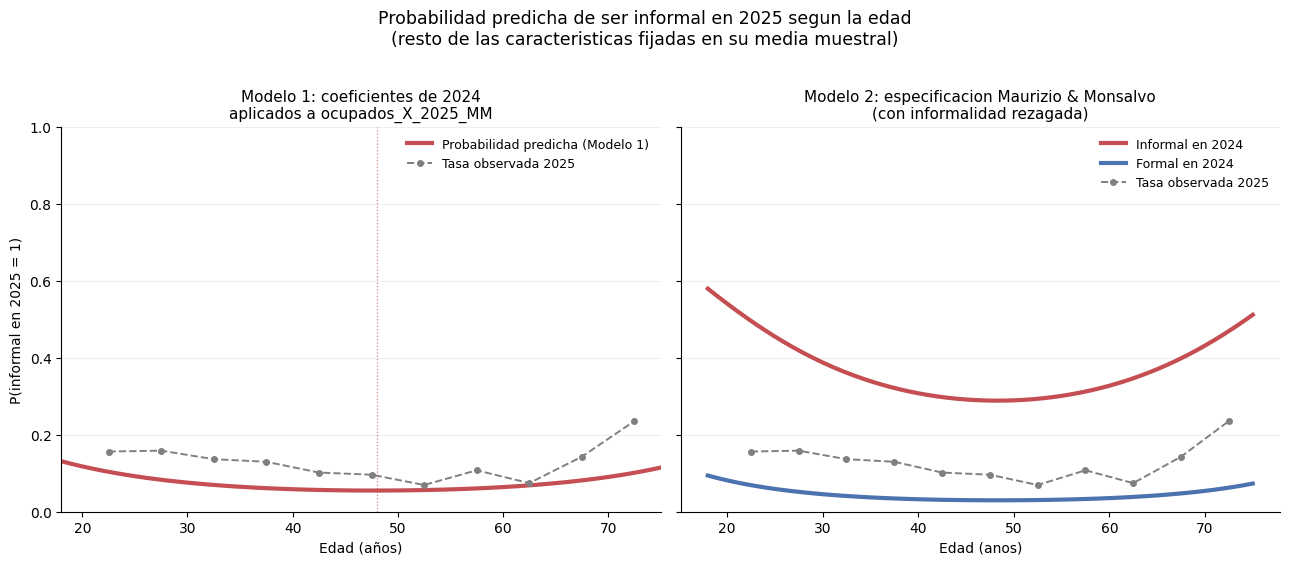

 edad  p_modelo1  p_m2_formal_previo  p_m2_informal_previo  brecha_persistencia
   20     0.1176              0.0815                0.5407               0.4591
   30     0.0755              0.0456                0.3876               0.3421
   40     0.0584              0.0324                0.3076               0.2752
   50     0.0552              0.0298                0.2891               0.2594
   60     0.0640              0.0354                0.3271               0.2917
   70     0.0902              0.0541                0.4312               0.3771
Observaciones evaluadas: 2956
Tasa de informalidad observada en 2025: 0.1079
Probabilidad predicha media - Modelo 1: 0.1106
Probabilidad predicha media - Modelo 2: 0.1079
Informales predichos - Modelo 1: 100 de 2956 | observados: 319
Informales predichos - Modelo 2: 227 de 2956 | observados: 319
--- Matriz de confusion: Modelo 1 (2024 -> 2025) (umbral 0.5) ---
                Pred: Formal  Pred: Informal
Real: Formal            2598    

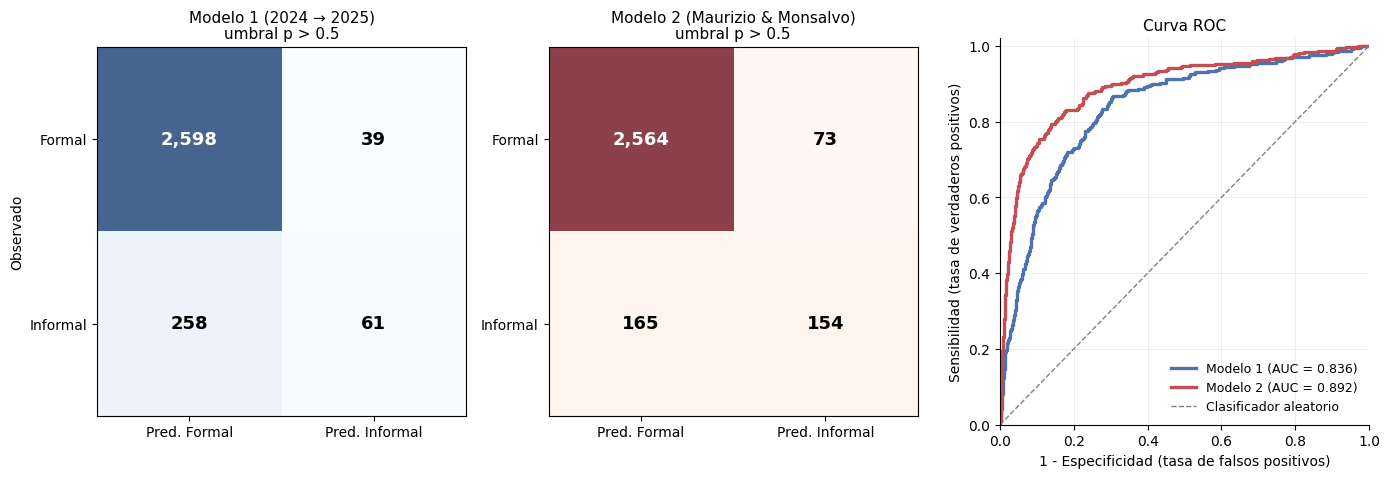

 Umbral   Modelo  Sensibilidad  Precision  Exactitud  FN (no alcanzados)  FP (filtracion)
   0.10 Modelo 1        0.7868     0.2780     0.7564                  68              652
   0.10 Modelo 2        0.7900     0.4098     0.8545                  67              363
   0.15 Modelo 1        0.6959     0.3308     0.8153                  97              449
   0.15 Modelo 2        0.7367     0.4767     0.8843                  84              258
   0.20 Modelo 1        0.6176     0.3655     0.8430                 122              342
   0.20 Modelo 2        0.6928     0.5351     0.9019                  98              192
   0.25 Modelo 1        0.5329     0.4087     0.8664                 149              246
   0.25 Modelo 2        0.6583     0.5882     0.9134                 109              147
   0.30 Modelo 1        0.4107     0.4267     0.8769                 188              176
   0.30 Modelo 2        0.6176     0.6099     0.9161                 122              126
   0.40 Mo

In [8]:
#%%
# =============================================================================
# TRABAJO PRÁCTICO 3
# =============================================================================

#%% 1.11. Creacion de las bases de datos anuales (Consigna A.1):

# 1.11.1. Crear las bases de datos por año (todavia con 'informal' e
# identificadores, que se necesitan para los pasos siguientes):
ocupados_X_2024 = ocupados[ocupados['ano'] == 2024].copy()
ocupados_X_2025 = ocupados[ocupados['ano'] == 2025].copy()

# 1.11.2. Separar las variables de respuesta (texto "Formal"/"Informal"):
y_2024 = ocupados_X_2024['informal']
y_2025 = ocupados_X_2025['informal']

# 1.11.3. Crear un codigo para hacer el 'join':
"""
CORRECCION: los identificadores se rellenan con ceros a la izquierda
(zfill) antes de concatenarse. Si 'cod_vivienda' o 'componente' pasaron
en algun momento por un tipo numerico, .astype(str) elimina los ceros
iniciales y dos individuos distintos pueden generar el mismo 'id' (o un
mismo individuo generar ids distintos en 2024 y 2025), lo que degrada
el match del panel. El separador '_' evita ademas colisiones del tipo
'12' + '3' = '1' + '23'.
"""
for df in [ocupados_X_2024, ocupados_X_2025]:
    df['id'] = (
        df['cod_vivienda'].astype(str).str.strip().str.zfill(6) + '_' +
        df['nro_hogar'].astype(str).str.strip().str.zfill(2)   + '_' +
        df['componente'].astype(str).str.strip().str.zfill(2)
    )

# Control de unicidad del identificador dentro de cada año:
print("Duplicados de 'id' en 2024:", ocupados_X_2024['id'].duplicated().sum())
print("Duplicados de 'id' en 2025:", ocupados_X_2025['id'].duplicated().sum())

#%% 1.12. Unificacion de la base de datos (Consigna A.1, extension Maurizio & Monsalvo):

# 1.12.1. Añadir la variable id a la base que aporta el estatus 2024:
y_2024_df = pd.DataFrame({
    'id':            ocupados_X_2024['id'],
    'informal_2024': y_2024
})

# 1.12.2. Unificar la base de datos mediante un inner join por 'id':
"""
'informal' (el estatus 2025, variable objetivo del Modelo 2) se
mantiene en ocupados_X_2025_MM hasta el paso 1.12.4, donde se extrae
directamente desde esta misma tabla. Esto evita el error de alineacion
que ocurre al intentar reconstruir y_2025_MM con un 'reindex' sobre
'ocupados_X_2025_MM.index': 'DataFrame.merge' NO conserva el indice
original de 'ocupados_X_2025', sino que genera un RangeIndex nuevo, por
lo que reindexar contra 'y_2025' (que si conserva el indice original)
producia practicamente todo NaN.
"""
ocupados_X_2025_MM = ocupados_X_2025.merge(
    y_2024_df,
    on  = 'id',
    how = 'inner'
).drop(columns = ['id', 'cod_vivienda', 'nro_hogar', 'componente', 'ano', 'trimestre'])

print("Estructura de ocupados_X_2025 (original):", ocupados_X_2025.shape)
print("Estructura de ocupados_X_2025_MM (con el 'join'):", ocupados_X_2025_MM.shape)
print("Tasa de supervivencia del panel:",
      round(len(ocupados_X_2025_MM) / len(ocupados_X_2025), 4))

# 1.12.3. Suprimir las variables duplicadas resultantes del 'join':
duplicadas_MM = ocupados_X_2025_MM.columns[ocupados_X_2025_MM.columns.duplicated()].tolist()
print("Columnas duplicadas detectadas en ocupados_X_2025_MM:", duplicadas_MM)
ocupados_X_2025_MM = ocupados_X_2025_MM.loc[:, ~ocupados_X_2025_MM.columns.duplicated(keep = "first")]
print("Duplicadas restantes:", ocupados_X_2025_MM.columns.duplicated().sum())

# 1.12.4. Extraer y_2025_MM DESDE ocupados_X_2025_MM (alineacion garantizada
# por ser la misma tabla) y recien despues eliminar 'informal' de X:
y_2025_MM = ocupados_X_2025_MM['informal']
ocupados_X_2025_MM = ocupados_X_2025_MM.drop(columns = 'informal')

print("Observaciones de y_2025_MM:", y_2025_MM.shape[0])
print("Indices alineados con ocupados_X_2025_MM:",
      y_2025_MM.index.equals(ocupados_X_2025_MM.index))

#%% 1.13. Supresion de variables redundantes, tautologicas y no
#        caracteristicas (aplicado por igual a las tres bases):

"""
Se suprimen cuatro grupos de columnas ANTES del one-hot encoding, de
manera que ninguna de sus dummies llegue a generarse:

(i)   Identificadoras / de agrupacion, sin valor como caracteristica
      individual una vez separadas las bases por año.
(ii)  Crudas numericas redundantes: codigos originales de la EPH que
      ya tienen su version etiquetada con sufijo '_cat' (o dummy en
      1.6). Quedaron en la base como numericas, por lo que el
      renombre (1.7) no las convirtio en texto ni las elimino.
(iii) Definitorias de 'informal' (paso 1.9): su inclusion en X
      implica tautologia, ya que el modelo terminaria "prediciendo"
      la variable objetivo a partir de sus propios insumos de
      construccion, y no de caracteristicas independientes del
      individuo.
(iv)  No caracteristicas: el ponderador muestral y la condicion de
      actividad (constante, todos son ocupados).
"""

id_y_agrupacion = [
    'id', 'cod_vivienda', 'nro_hogar', 'componente',
    'ano', 'año', 'trimestre',
]

crudas_redundantes = [
    'CH04', 'CH07', 'CH08',
    'nivel_ed', 'cat_ocup', 'tipo_sector', 'tipo_empleo',
    'region', 'comprobante_sal', 'alcance_recibo', 'parte_sueldo',
    'desc_jub_cod', 'tam_estab_cod',
]

definitorias_informal = [
    'cat_ocup2', 'desc_jubilatorio',
    'tam_estab', 'tam_estab_agrup',
    'sector_2', 'tipo_sector_cat', 'tipo_empleo_cat',
    'comprobante_sal_cat', 'alcance_recibo_cat',
    'parte_sueldo_cat', 'cat_ocup_cat'
]

no_caracteristicas = ['ponderador', 'cond_actividad']

vars_a_suprimir = (
    id_y_agrupacion + crudas_redundantes +
    definitorias_informal + no_caracteristicas
)

for nombre in ['ocupados_X_2024', 'ocupados_X_2025', 'ocupados_X_2025_MM']:
    df = globals()[nombre]
    presentes = [c for c in vars_a_suprimir if c in df.columns]
    globals()[nombre] = df.drop(columns = presentes)
    print(f"{nombre}: suprimidas {len(presentes)} columnas -> "
          f"estructura {globals()[nombre].shape}")

# 1.13.1. Suprimir 'informal' de ocupados_X_2024 y ocupados_X_2025
# (ya se extrajo como y_2024 e y_2025 en 1.11.2):
ocupados_X_2024 = ocupados_X_2024.drop(columns = 'informal', errors = 'ignore')
ocupados_X_2025 = ocupados_X_2025.drop(columns = 'informal', errors = 'ignore')

#%% 1.14. One hot encoding de las variables cualitativas:

# 1.14.1. Encoding conjunto de ocupados_X_2024 y ocupados_X_2025:
"""
Para que la tabla de diferencia de medias (Consigna A.2) compare
exactamente las mismas variables en ambos años, el one-hot encoding se
aplica sobre las dos bases EN CONJUNTO: si una categoria estuviera
presente solo en un año, encodear por separado generaria columnas de
dummies distintas y no comparables entre si.
"""

ocupados_X_2024['_origen'] = '2024'
ocupados_X_2025['_origen'] = '2025'

union_24_25 = pd.concat([ocupados_X_2024, ocupados_X_2025], ignore_index = True)

cualitativas_24_25 = union_24_25.select_dtypes(include = 'object').columns.tolist()
cualitativas_24_25 = [c for c in cualitativas_24_25 if c != '_origen']

print("Variables cualitativas identificadas (2024/2025):", cualitativas_24_25)

union_24_25 = pd.get_dummies(
    union_24_25,
    columns    = cualitativas_24_25,
    drop_first = True,
    dummy_na   = False
)

bool_cols_24_25 = union_24_25.select_dtypes(include = bool).columns.tolist()
union_24_25[bool_cols_24_25] = union_24_25[bool_cols_24_25].astype(int)

ocupados_X_2024 = union_24_25[union_24_25['_origen'] == '2024'].drop(columns = '_origen')
ocupados_X_2025 = union_24_25[union_24_25['_origen'] == '2025'].drop(columns = '_origen')

print("Estructura ocupados_X_2024:", ocupados_X_2024.shape)
print("Estructura ocupados_X_2025:", ocupados_X_2025.shape)
print("Mismas columnas en ambas bases:",
      set(ocupados_X_2024.columns) == set(ocupados_X_2025.columns))

# 1.14.1.bis. REALINEACION DE LOS VECTORES OBJETIVO (CORRECCION CLAVE):
"""
'pd.concat(..., ignore_index = True)' descarta el indice original y
genera un RangeIndex nuevo sobre la union. Al volver a separar las
bases, 'ocupados_X_2024' y 'ocupados_X_2025' quedan con posiciones de
ese RangeIndex, mientras que 'y_2024' e 'y_2025' conservan el indice
original de 'ocupados' (paso 1.11.2).

Esto importa porque en 1.2 de la Parte B se hace
'pd.concat([y_2024_bin, ocupados_X_2024], axis = 1)', y 'concat' con
axis = 1 alinea POR INDICE, no por posicion. Si los indices no se
corresponden, cada individuo queda emparejado con el estatus de
informalidad de otra persona (o queda NaN y se pierde en el dropna),
y el logit termina ajustando contra ruido: coeficientes colapsados
hacia cero, errores estandar grandes y pseudo-R2 nulo.

Como el orden de las filas SI se preserva a lo largo de todo el
proceso (concat apila 2024 y despues 2025, y el filtro por '_origen'
respeta ese orden), basta con reiniciar ambos indices para restaurar
la correspondencia posicional.
"""

ocupados_X_2024 = ocupados_X_2024.reset_index(drop = True)
ocupados_X_2025 = ocupados_X_2025.reset_index(drop = True)

y_2024 = y_2024.reset_index(drop = True)
y_2025 = y_2025.reset_index(drop = True)

print("Alineacion 2024 -> filas X:", len(ocupados_X_2024),
      "| filas y:", len(y_2024),
      "| indices identicos:", ocupados_X_2024.index.equals(y_2024.index))
print("Alineacion 2025 -> filas X:", len(ocupados_X_2025),
      "| filas y:", len(y_2025),
      "| indices identicos:", ocupados_X_2025.index.equals(y_2025.index))

# 1.14.2. Encoding de ocupados_X_2025_MM (por separado, porque incluye
# el regresor adicional 'informal_2024' que no existe en las otras dos):
cualitativas_MM = ocupados_X_2025_MM.select_dtypes(include = 'object').columns.tolist()

print("Variables cualitativas identificadas (2025_MM):", cualitativas_MM)

for var in cualitativas_MM:
    n_cat = ocupados_X_2025_MM[var].nunique(dropna = True)
    naturaleza = "binaria" if n_cat == 2 else "nominal (>2 categorias)"
    print(f"{var}: {n_cat} categorias -> {naturaleza}")

ocupados_X_2025_MM = pd.get_dummies(
    ocupados_X_2025_MM,
    columns    = cualitativas_MM,
    drop_first = True,
    dummy_na   = False
)

bool_cols_MM = ocupados_X_2025_MM.select_dtypes(include = bool).columns.tolist()
ocupados_X_2025_MM[bool_cols_MM] = ocupados_X_2025_MM[bool_cols_MM].astype(int)

print("Estructura ocupados_X_2025_MM:", ocupados_X_2025_MM.shape)

# 1.14.2.bis. Control de compatibilidad entre train y test:
"""
El encoding de 2025_MM corre por separado, por lo que la categoria de
referencia descartada por drop_first podria diferir de la de 2024 y
generar nombres de dummies incompatibles. El control siguiente lo
verifica de forma explicita: si aparecen columnas en 2024 que no estan
en 2025_MM, la prediccion fuera de muestra (B.2 y Parte C) no seria
valida sin un realineamiento previo.
"""
solo_en_2024 = sorted(set(ocupados_X_2024.columns) - set(ocupados_X_2025_MM.columns))
solo_en_MM   = sorted(set(ocupados_X_2025_MM.columns) - set(ocupados_X_2024.columns))

print("Columnas en 2024 ausentes en 2025_MM:", solo_en_2024)
print("Columnas en 2025_MM ausentes en 2024:", solo_en_MM)

#%% 2. Analisis descriptivo y diferencia de medias (Consigna A.2):

# 2.1. Estadisticos descriptivos de ocupados_X_2025_MM:
ocupados_X_2025_MM_to_excel = ocupados_X_2025_MM.describe().T

ocupados_X_2025_MM_to_excel.to_excel(
    "ocupados_X_2025_MM_describe.xlsx",
    sheet_name   = "Descriptiva",
    float_format = "%.4f"
)

# 2.2. Tabla de diferencia de medias entre ocupados_X_2024 y ocupados_X_2025:
"""
Balance Table Train vs Test Sample: para cada caracteristica comun a
ambas bases (ya con las mismas columnas tras el encoding conjunto de
1.14.1) se calcula la media 2024, la media 2025, la diferencia
(2025 - 2024) y el estadistico t de Welch (varianzas no necesariamente
iguales) de un contraste de diferencia de medias.
"""

from scipy import stats

columnas_comunes = [
    c for c in ocupados_X_2024.columns
    if c in ocupados_X_2025.columns
]

resultados_medias = []

for var in columnas_comunes:
    x_24 = ocupados_X_2024[var].dropna()
    x_25 = ocupados_X_2025[var].dropna()

    media_24   = x_24.mean()
    media_25   = x_25.mean()
    diferencia = media_25 - media_24

    t_stat, p_valor = stats.ttest_ind(x_25, x_24, equal_var = False, nan_policy = "omit")

    resultados_medias.append({
        "variable":      var,
        "media_2024":    media_24,
        "media_2025":    media_25,
        "diferencia":    diferencia,
        "t_estadistico": t_stat,
        "p_valor":       p_valor
    })

tabla_diferencia_medias = pd.DataFrame(resultados_medias).set_index("variable")

# Marca de significatividad para facilitar la lectura de la tabla:
tabla_diferencia_medias['significativa_5pct'] = (
    tabla_diferencia_medias['p_valor'] < 0.05
)

print(tabla_diferencia_medias.round(4))
print("Caracteristicas con diferencia significativa al 5%:",
      int(tabla_diferencia_medias['significativa_5pct'].sum()),
      "de", len(tabla_diferencia_medias))

tabla_diferencia_medias.to_excel(
    "tabla_diferencia_medias.xlsx",
    sheet_name   = "Diferencia_medias",
    float_format = "%.4f"
)

#%%
# =============================================================================
# PARTE B: MODELO DE REGRESION LOGISTICA
# =============================================================================

#%% 1. Estimacion de los modelos de Regresion Logistica (Consigna B.1,
#      extension de Maurizio & Monsalvo, 2021):

"""
Modelo 1 (ocupados_X_2024): logit de informalidad 2024 sobre las
caracteristicas X de 2024, sin informalidad rezagada.

Modelo 2 (ocupados_X_2025_MM): logit de informalidad 2025 sobre las
caracteristicas X de 2025 mas 'informal_2024_Informal' (dummy de
informalidad rezagada, incorporada en el 'join' de 1.12 y encodeada en
1.14.2), siguiendo la especificacion de Maurizio & Monsalvo (2021), que
introduce el estatus de informalidad del periodo anterior como regresor
adicional (Seccion 4.1 del paper, ecuaciones 1 y 2).

Ambas matrices de caracteristicas ya llegan limpias de 1.13 (sin
identificadores, sin crudas redundantes, sin variables definitorias de
'informal' y sin ponderador/condicion de actividad), por lo que aca solo
resta binarizar el vector objetivo, alinear observaciones, depurar
representaciones redundantes, estandarizar las variables continuas y
estimar.
"""

# 1.1. Vectores objetivo binarios (0 = Formal, 1 = Informal):
y_2024_bin    = y_2024.map({'Formal': 0, 'Informal': 1})
y_2025_MM_bin = y_2025_MM.map({'Formal': 0, 'Informal': 1})

print("Distribucion y_2024_bin:")
print(y_2024_bin.value_counts())
print("Tasa de informalidad 2024:", round(y_2024_bin.mean(), 4))

print("Distribucion y_2025_MM_bin:")
print(y_2025_MM_bin.value_counts())
print("Tasa de informalidad 2025 (panel MM):", round(y_2025_MM_bin.mean(), 4))

# 1.2. Alinear observaciones y eliminar NaN (statsmodels no admite NaN):
"""
Tras la correccion de 1.14.1.bis los indices de y_2024_bin y
ocupados_X_2024 coinciden, por lo que este concat empareja cada
individuo con su propio estatus de informalidad. El assert deja el
control explicito en el codigo: si el alineamiento se rompiera al
modificar pasos anteriores, la ejecucion se detiene aca en lugar de
producir un modelo silenciosamente mal estimado.
"""

assert y_2024_bin.index.equals(ocupados_X_2024.index), \
    "y_2024 y ocupados_X_2024 no estan alineados (revisar 1.14.1.bis)"
assert y_2025_MM_bin.index.equals(ocupados_X_2025_MM.index), \
    "y_2025_MM y ocupados_X_2025_MM no estan alineados (revisar 1.12.4)"

datos_2024 = pd.concat(
    [y_2024_bin.rename('y'), ocupados_X_2024], axis = 1
).dropna()
y_2024_final = datos_2024['y']
X_2024_raw   = datos_2024.drop(columns = 'y')

datos_2025_MM = pd.concat(
    [y_2025_MM_bin.rename('y'), ocupados_X_2025_MM], axis = 1
).dropna()
y_2025_MM_final = datos_2025_MM['y']
X_2025_MM_raw   = datos_2025_MM.drop(columns = 'y')

print("Observaciones Modelo 1 (2024):", X_2024_raw.shape)
print("Observaciones Modelo 2 (2025_MM):", X_2025_MM_raw.shape)
print("Tasa de informalidad tras el dropna (2024):", round(y_2024_final.mean(), 4))
print("Tasa de informalidad tras el dropna (2025_MM):", round(y_2025_MM_final.mean(), 4))

# 1.3. Excluir representaciones redundantes de educacion y otras
# colinealidades identificadas en el diagnostico de errores estandar:

"""
El modelo incluye cinco representaciones del mismo concepto educativo
(educ, nivel_ed2, nivel_ed_cat, nivel_ed_alto, nivel_ed_aprb). Su
inclusion simultanea genera multicolinealidad severa que impide la
inversion de la Hessiana y produce errores estandar igual a NaN. Se
conserva unicamente 'educ' (anos de educacion formal, continua) por ser
la especificacion de Maurizio & Monsalvo (2021). Se elimina tambien
'horastrabj' (colineal con 'horastrab') y 'cod_ocupacion' (categorica
de alta cardinalidad que no aporta como regresora directa en el logit).

Sobre 'ingreso_total': se mantiene como regresor pero conviene notar
que su relacion con la informalidad es en parte mecanica (el empleo no
registrado paga sistematicamente menos), por lo que puede absorber
parte del efecto de 'educ' y 'edad'. El flag EXCLUIR_INGRESO permite
estimar la especificacion alternativa sin esa variable y comparar la
estabilidad de los coeficientes de interes; es un chequeo de robustez
util para comentar en el informe.
"""

EXCLUIR_INGRESO = False   # cambiar a True para el chequeo de robustez

redundantes_logit = [
    # Representaciones redundantes de educacion (se conserva 'educ'):
    'nivel_ed2_Superior',
    'nivel_ed_cat_Primario incompleto',
    'nivel_ed_cat_Secundario completo',
    'nivel_ed_cat_Secundario incompleto',
    'nivel_ed_cat_Sin instruccion',
    'nivel_ed_cat_Superior completo',
    'nivel_ed_cat_Superior incompleto',
    'nivel_ed_alto_Jardín/preescolar',
    'nivel_ed_alto_Polimodal',
    'nivel_ed_alto_Posgrado universitario',
    'nivel_ed_alto_Primario',
    'nivel_ed_alto_Secundario',
    'nivel_ed_alto_Terciario',
    'nivel_ed_alto_Universitario',
    'nivel_ed_aprb_Ninguno',
    'nivel_ed_aprb_Noveno',
    'nivel_ed_aprb_Octavo',
    'nivel_ed_aprb_Primero',
    'nivel_ed_aprb_Quinto',
    'nivel_ed_aprb_Segundo',
    'nivel_ed_aprb_Sexto',
    'nivel_ed_aprb_Séptimo',
    'nivel_ed_aprb_Tercero',
    'ingreso_ppal',
    'finalizacion_nivel_Sí',
    'cat_ocup_cat_Patron',
    # Colineal con las variables de horas de trabajo:
    'horastrabj',
    'horastrab',
    # Alta cardinalidad sin valor directo como regresora:
    'cod_ocupacion',
]

if EXCLUIR_INGRESO:
    redundantes_logit = redundantes_logit + ['ingreso_total']

X_2024_raw = X_2024_raw.drop(
    columns = [c for c in redundantes_logit if c in X_2024_raw.columns]
)
X_2025_MM_raw = X_2025_MM_raw.drop(
    columns = [c for c in redundantes_logit if c in X_2025_MM_raw.columns]
)

print("Columnas en X_2024_raw tras excluir redundantes:",    X_2024_raw.shape[1])
print("Columnas en X_2025_MM_raw tras excluir redundantes:", X_2025_MM_raw.shape[1])

# 1.4. Eliminar columnas con varianza cero o cuasi-cero (std < 0.01):

"""
Las columnas con varianza cero son constantes en la muestra y no
aportan informacion al modelo; ademas causan singularidad en la
Hessiana. Se usa un umbral de std < 0.01 para incluir tambien las
cuasi-constantes (categorias con menos del 1% de los casos, como
ciertas dummies de parentesco o nivel educativo extremo).

CORRECCION: el criterio se calcula UNA sola vez sobre la muestra de
entrenamiento (2024) y la misma lista se aplica a la de testeo. Aplicar
el filtro por separado a cada base puede eliminar columnas distintas en
cada una y dejar los dos modelos con conjuntos de regresores no
comparables, lo que invalidaria tanto la tabla conjunta de B.1 como la
prediccion fuera de muestra de B.2 y la Parte C. Estimar sobre train y
trasladar la decision a test es ademas el procedimiento metodologicamente
correcto: ninguna decision de especificacion debe tomarse mirando la
muestra de testeo.
"""

cols_bajas = X_2024_raw.columns[X_2024_raw.std() < 0.01].tolist()
print("Columnas eliminadas por varianza baja (criterio 2024):", cols_bajas)

X_2024_raw = X_2024_raw.drop(columns = cols_bajas)
X_2025_MM_raw = X_2025_MM_raw.drop(
    columns = [c for c in cols_bajas if c in X_2025_MM_raw.columns]
)

# 1.4.bis. Forzar que la base de testeo tenga exactamente los regresores
# de la base de entrenamiento, mas la informalidad rezagada:
"""
Garantiza la comparabilidad columna a columna entre ambos modelos. Si
alguna dummy estuviera ausente en 2025_MM se agrega en cero (la
categoria no se observa en el panel), y cualquier columna sobrante que
el Modelo 1 desconoce se descarta, salvo el regresor de Maurizio &
Monsalvo.
"""

REZAGO = 'informal_2024_Informal'

columnas_modelo = X_2024_raw.columns.tolist()
columnas_MM     = columnas_modelo + ([REZAGO] if REZAGO in X_2025_MM_raw.columns else [])

agregadas   = [c for c in columnas_modelo if c not in X_2025_MM_raw.columns]
descartadas = [c for c in X_2025_MM_raw.columns if c not in columnas_MM]

print("Columnas agregadas en cero a 2025_MM:", agregadas)
print("Columnas descartadas de 2025_MM:",      descartadas)

X_2025_MM_raw = X_2025_MM_raw.reindex(columns = columnas_MM, fill_value = 0)

print("Regresores Modelo 1:", X_2024_raw.shape[1])
print("Regresores Modelo 2:", X_2025_MM_raw.shape[1])

# 1.5. Estandarizar las variables continuas (media 0, desv. std 1):

"""
Las variables continuas (edad, edad2, educ, horas, ingresos, nhogar)
tienen escalas muy distintas a las dummies (0/1). Sin estandarizacion
el algoritmo BFGS no puede calcular gradientes utiles y los coeficientes
colapsan a cero o la Hessiana no puede invertirse. Se estandarizan solo
las continuas para mantener la interpretabilidad de las dummies.
El scaler de 2024 se ajusta ('fit') sobre 2024 y se aplica ('transform')
sobre 2025_MM, de manera que la escala de referencia sea siempre la
muestra de entrenamiento.

Se conserva ademas una copia de las continuas SIN estandarizar
(X_2025_MM_originales), necesaria para que el eje horizontal del grafico
de B.2 pueda expresarse en unidades interpretables (anos de edad, anos
de educacion) en lugar de desvios estandar.
"""

continuas = [
    'edad', 'edad2', 'educ', 'horastrab',
    'horas_s_principal', 'horas_s_otras_act',
    'nhogar', 'ingreso_ppal', 'ingreso_total',
    'cant_ocupaciones_ad',
]

cols_cont = [c for c in continuas if c in X_2024_raw.columns]
print("Variables continuas estandarizadas:", cols_cont)

# Copia previa a la transformacion (para B.2):
X_2024_originales    = X_2024_raw[cols_cont].copy()
X_2025_MM_originales = X_2025_MM_raw[cols_cont].copy()

scaler = StandardScaler()

X_2024_raw = X_2024_raw.copy()
X_2024_raw[cols_cont] = scaler.fit_transform(X_2024_raw[cols_cont])

X_2025_MM_raw = X_2025_MM_raw.copy()
X_2025_MM_raw[cols_cont] = scaler.transform(X_2025_MM_raw[cols_cont])

# Diccionario media/desvio por variable, para revertir la
# estandarizacion cuando haga falta:
params_scaler = pd.DataFrame({
    'media':  scaler.mean_,
    'desvio': scaler.scale_
}, index = cols_cont)

print(params_scaler.round(3))

# 1.6. Diagnostico de rango final:
from numpy.linalg import matrix_rank

X_2024_final    = sm.add_constant(X_2024_raw)
X_2025_MM_final = sm.add_constant(X_2025_MM_raw)

print("Rango / columnas Modelo 1:",
      matrix_rank(X_2024_final), "/", X_2024_final.shape[1])
print("Rango / columnas Modelo 2:",
      matrix_rank(X_2025_MM_final), "/", X_2025_MM_final.shape[1])

# 1.7. Estimacion del Modelo 1 (2024):
modelo_2024 = sm.Logit(y_2024_final, X_2024_final).fit(
    method  = 'bfgs',
    maxiter = 1000,
    disp    = True
)
print(modelo_2024.summary())

# 1.8. Estimacion del Modelo 2 (2025_MM, especificacion Maurizio & Monsalvo):
modelo_2025_MM = sm.Logit(y_2025_MM_final, X_2025_MM_final).fit(
    method  = 'bfgs',
    maxiter = 1000,
    disp    = True
)
print(modelo_2025_MM.summary())

# 1.8.bis. Diagnostico de ajuste:
"""
Control de sanidad tras la correccion del alineamiento. Un pseudo-R2
cercano a cero en el Modelo 1, con decenas de regresores y varios miles
de observaciones, indicaria que el vector objetivo no se corresponde
fila a fila con la matriz de caracteristicas.
"""
print("Pseudo-R2 Modelo 1:", round(modelo_2024.prsquared, 4),
      "| LLR p-valor:", round(modelo_2024.llr_pvalue, 6))
print("Pseudo-R2 Modelo 2:", round(modelo_2025_MM.prsquared, 4),
      "| LLR p-valor:", round(modelo_2025_MM.llr_pvalue, 6))

#%% 1.9. Tabla de coeficientes, EMP, errores estandar y odds-ratios
#        (Consigna B.1 items i, ii y iii):

"""
Para cada modelo se extraen de statsmodels:
- Coeficientes estimados (params)
- Errores estandar (bse)
- Odds-ratios: exp(coef), interpretados como el cambio multiplicativo
  en los odds de ser informal ante un incremento unitario en X.
- Efectos Marginales Promedio (EMP): se calcula el efecto marginal
  en cada observacion y luego se promedia sobre la muestra
  (get_margeff() con method='dydx', at='mean' calcula el efecto en
  la media de X; se usa at='overall' para el promedio sobre toda la
  distribucion observada, que es el EMP propiamente dicho).
- p-valores, que permiten leer la significatividad directamente en la
  tabla sin recurrir al summary completo.
"""

# 1.9.1. Funcion auxiliar para construir la tabla de un modelo:
def tabla_logit(modelo, nombre_modelo):
    margeff = modelo.get_margeff(at = 'overall', method = 'dydx')

    # coef, bse y odds: excluir 'const' para alinear con los EMP
    # (get_margeff no calcula efecto marginal de la constante):
    vars_sin_const = [v for v in modelo.params.index if v != 'const']

    coef   = modelo.params[vars_sin_const]
    bse    = modelo.bse[vars_sin_const]
    pval   = modelo.pvalues[vars_sin_const]
    odds   = np.exp(coef)
    emp    = pd.Series(margeff.margeff,    index = vars_sin_const)
    emp_se = pd.Series(margeff.margeff_se, index = vars_sin_const)

    estrellas = pd.Series(
        np.select(
            [pval < 0.01, pval < 0.05, pval < 0.10],
            ['***', '**', '*'],
            default = ''
        ),
        index = vars_sin_const
    )

    tabla = pd.DataFrame({
        'Coeficiente':    coef,
        'Error estandar': bse,
        'p-valor':        pval,
        'Signif.':        estrellas,
        'Odds-ratio':     odds,
        'EMP':            emp,
        'EMP std. error': emp_se,
    })
    tabla.index.name = 'Variable'
    tabla.columns = pd.MultiIndex.from_tuples(
        [(nombre_modelo, c) for c in tabla.columns]
    )
    return tabla

# 1.9.2. Construir la tabla para cada modelo:
tabla_m1 = tabla_logit(modelo_2024,    'Modelo 1 (2024)')
tabla_m2 = tabla_logit(modelo_2025_MM, 'Modelo 2 (2025 MM)')

# 1.9.3. Unir ambas tablas en columnas:
tabla_conjunta = tabla_m1.join(tabla_m2, how = 'outer').round(4)

print(tabla_conjunta.to_string())

# 1.9.4. Comparacion focalizada en las variables que pide la consigna:
"""
La consigna pregunta si los coeficientes de caracteristicas como edad o
educacion cambian al introducir el estatus de informalidad rezagado.
Este extracto aisla esas filas para facilitar la comparacion directa.
"""
vars_interes = ['edad', 'edad2', 'educ', 'sexo_Masculino', REZAGO]
vars_presentes = [v for v in vars_interes if v in tabla_conjunta.index]

print(tabla_conjunta.loc[vars_presentes].to_string())

# 1.9.5. Exportar a Excel:
tabla_conjunta.to_excel(
    "tabla_coef_logit.xlsx",
    sheet_name   = "Coef_EMP_OR",
    float_format = "%.4f"
)


#%% 2. Visualizacion de la probabilidad predicha (Consigna B.2):

"""
Se grafica P(Y25 = 1 | ocupados_X_2025_MM) contra la edad, siguiendo el
estilo de la ilustracion de clase: en lugar de una nube de puntos
individuales, se trazan curvas suaves construidas manteniendo TODAS las
demas caracteristicas fijas en su valor promedio en la base de testeo y
haciendo variar unicamente la edad a lo largo de su rango observado.
Esto aisla el efecto de la caracteristica seleccionada, que es lo que
permite interpretar la curva.

Se eligio la edad porque en la tabla de B.1 'edad' y 'edad2' resultan
significativas al 1% en ambos modelos, con signos opuestos (-1.24 y
+1.21 en el Modelo 1), lo que implica una relacion convexa en forma de U:
probabilidad alta de informalidad al inicio de la vida laboral, minimo
en las edades centrales y repunte hacia el final. La educacion, aunque
tambien significativa, genera una curva monotona menos ilustrativa.

Panel izquierdo  -> Modelo 1, que es lo que pide literalmente la
                    consigna ('coeficientes estimados de 2024' aplicados
                    a los datos de testeo).
Panel derecho    -> Modelo 2, que al incluir la informalidad rezagada
                    permite trazar dos curvas y visualizar la
                    persistencia del estatus informal, nucleo de la
                    extension de Maurizio & Monsalvo (2021).
"""

import matplotlib.pyplot as plt

# 2.1. Manejo consistente de 'edad' y 'edad2':
"""
Al construir la grilla NO alcanza con mover 'edad': 'edad2' es su
cuadrado y debe recorrer la grilla en forma simultanea. Si se dejara
'edad2' fija en su media mientras 'edad' varia, la curva resultante no
correspondería a ningun individuo posible y el termino cuadratico
quedaria neutralizado.

Ambas variables estan estandarizadas (paso 1.5), de modo que la grilla
se construye en anos, se eleva al cuadrado en niveles y recien despues
se estandariza cada componente con su propia media y desvio.
"""

media_edad   = params_scaler.loc['edad',  'media']
desvio_edad  = params_scaler.loc['edad',  'desvio']
media_edad2  = params_scaler.loc['edad2', 'media']
desvio_edad2 = params_scaler.loc['edad2', 'desvio']

# Rango observado de edad en la base de testeo (en anos):
edad_anos_obs = X_2025_MM_originales['edad']
#edad_min = int(np.floor(edad_anos_obs.min()))
#edad_max = int(np.ceil(edad_anos_obs.max()))
edad_min = 18
edad_max = 75

print("Rango de edad en la base de testeo:", edad_min, "a", edad_max, "anos")

grilla_edad  = np.arange(edad_min, edad_max + 1, 1)
grilla_edad_std  = (grilla_edad         - media_edad)  / desvio_edad
grilla_edad2_std = (grilla_edad ** 2    - media_edad2) / desvio_edad2

# 2.2. Alinear la base de testeo con los regresores de cada modelo:
"""
El Modelo 1 desconoce 'informal_2024_Informal', por lo que al predecir
sobre la base MM esa columna debe descartarse. El reindex contra el
indice de coeficientes de cada modelo garantiza que las columnas entren
en el orden correcto.
"""

X_test_m1 = X_2025_MM_final.reindex(
    columns = modelo_2024.params.index, fill_value = 0
)
X_test_m2 = X_2025_MM_final.reindex(
    columns = modelo_2025_MM.params.index, fill_value = 0
)

print("Regresores Modelo 1 ausentes en testeo:",
      [c for c in modelo_2024.params.index if c not in X_2025_MM_final.columns])
print("Regresores Modelo 2 ausentes en testeo:",
      [c for c in modelo_2025_MM.params.index if c not in X_2025_MM_final.columns])

# 2.3. Funcion que construye la curva ceteris paribus:
def curva_edad(modelo, X_test, valor_rezago = None):
    """
    Replica el perfil promedio de la base de testeo tantas veces como
    puntos tiene la grilla, sustituye edad y edad2 por sus valores de
    grilla y (opcionalmente) fija el estatus de informalidad rezagado.
    """
    perfil = pd.concat(
        [X_test.mean().to_frame().T] * len(grilla_edad),
        ignore_index = True
    )
    perfil['const'] = 1.0
    perfil['edad']  = grilla_edad_std
    perfil['edad2'] = grilla_edad2_std

    if valor_rezago is not None and REZAGO in perfil.columns:
        perfil[REZAGO] = valor_rezago

    return modelo.predict(perfil[modelo.params.index])

p_m1            = curva_edad(modelo_2024,    X_test_m1)
p_m2_formal     = curva_edad(modelo_2025_MM, X_test_m2, valor_rezago = 0)
p_m2_informal   = curva_edad(modelo_2025_MM, X_test_m2, valor_rezago = 1)

# 2.4. Tasa de informalidad observada por tramo de edad (referencia empirica):
"""
Se agrupa en tramos quinquenales en lugar de anos simples para evitar
el ruido de celdas con pocos casos.
"""

obs = pd.DataFrame({
    'edad':      edad_anos_obs.values,
    'observado': y_2025_MM_final.values
})
obs['tramo'] = (obs['edad'] // 5) * 5 + 2.5

tasa_obs = obs.groupby('tramo').agg(
    tasa = ('observado', 'mean'),
    n    = ('observado', 'size')
).reset_index()
tasa_obs = tasa_obs[tasa_obs['n'] >= 30]

print(tasa_obs.round(4).to_string(index = False))

# 2.5. Edad que minimiza la probabilidad predicha (vertice de la U):
edad_minima_m1 = grilla_edad[np.argmin(p_m1)]
print("Edad de minima probabilidad predicha (Modelo 1):", edad_minima_m1, "anos")

# 2.6. Grafico:
fig, axes = plt.subplots(1, 2, figsize = (13, 5.5), sharey = True)

# --- Panel izquierdo: Modelo 1 ---
ax = axes[0]

ax.plot(grilla_edad, p_m1,
        color = '#C44E52', linewidth = 3,
        label = 'Probabilidad predicha (Modelo 1)')

ax.plot(tasa_obs['tramo'], tasa_obs['tasa'],
        color = 'grey', linewidth = 1.4, linestyle = '--',
        marker = 'o', markersize = 4,
        label = 'Tasa observada 2025')

ax.axvline(edad_minima_m1, color = '#C44E52',
           linewidth = 0.9, linestyle = ':', alpha = 0.7)

ax.set_title('Modelo 1: coeficientes de 2024\naplicados a ocupados_X_2025_MM',
             fontsize = 11)
ax.set_xlabel('Edad (años)')
ax.set_ylabel('P(informal en 2025 = 1)')
ax.legend(frameon = False, fontsize = 9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis = 'y', alpha = 0.25, linewidth = 0.6)

# --- Panel derecho: Modelo 2 ---
ax = axes[1]

ax.plot(grilla_edad, p_m2_informal,
        color = '#C44E52', linewidth = 3,
        label = 'Informal en 2024')

ax.plot(grilla_edad, p_m2_formal,
        color = '#4C72B0', linewidth = 3,
        label = 'Formal en 2024')

ax.plot(tasa_obs['tramo'], tasa_obs['tasa'],
        color = 'grey', linewidth = 1.4, linestyle = '--',
        marker = 'o', markersize = 4,
        label = 'Tasa observada 2025')

ax.set_title('Modelo 2: especificacion Maurizio & Monsalvo\n(con informalidad rezagada)',
             fontsize = 11)
ax.set_xlabel('Edad (anos)')
ax.legend(frameon = False, fontsize = 9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis = 'y', alpha = 0.25, linewidth = 0.6)

axes[0].set_ylim(0, 1)
axes[0].set_xlim(edad_min, edad_max)

fig.suptitle(
    'Probabilidad predicha de ser informal en 2025 segun la edad\n'
    '(resto de las caracteristicas fijadas en su media muestral)',
    fontsize = 12.5, y = 1.02
)

plt.tight_layout()
plt.savefig("B2_prob_informalidad_edad.png", dpi = 300, bbox_inches = 'tight')
plt.show()

# 2.7. Valores puntuales para citar en el informe:
resumen_curvas = pd.DataFrame({
    'edad':                 grilla_edad,
    'p_modelo1':            p_m1.values,
    'p_m2_formal_previo':   p_m2_formal.values,
    'p_m2_informal_previo': p_m2_informal.values,
})
resumen_curvas['brecha_persistencia'] = (
    resumen_curvas['p_m2_informal_previo'] - resumen_curvas['p_m2_formal_previo']
)

print(resumen_curvas[resumen_curvas['edad'].isin([20, 30, 40, 50, 60, 70])]
      .round(4).to_string(index = False))

resumen_curvas.to_excel(
    "B2_curvas_probabilidad.xlsx",
    sheet_name   = "Curvas",
    float_format = "%.4f",
    index        = False
)

#%%
# =============================================================================
# PARTE C: DESEMPENO DEL MODELO Y PREDICCION FUERA DE LA MUESTRA
# =============================================================================

#%% 1. Matriz de confusion, curva ROC y metricas (Consigna C.1):

"""
Ambos modelos se evaluan sobre la MISMA muestra de testeo
(ocupados_X_2025_MM) y contra el MISMO vector observado
(y_2025_MM_final), de modo que las metricas sean directamente
comparables.

Advertencia metodologica que conviene explicitar en el informe:

- El Modelo 1 se estimo con datos de 2024 y aca se aplica a 2025, por
  lo que sus metricas son genuinamente FUERA DE MUESTRA.
- El Modelo 2 se estimo sobre esta misma base 2025_MM, por lo que sus
  metricas son DENTRO DE MUESTRA y estan mecanicamente infladas. La
  comparacion entre ambos no es del todo simetrica: parte de la ventaja
  del Modelo 2 proviene de haber visto estos datos durante la
  estimacion, y no solo del poder predictivo de la informalidad
  rezagada.
"""

from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score
)
import matplotlib.pyplot as plt

# 1.1. Probabilidades predichas de cada modelo sobre la base de testeo:
prob_m1 = modelo_2024.predict(X_test_m1)
prob_m2 = modelo_2025_MM.predict(X_test_m2)

y_obs = y_2025_MM_final

print("Observaciones evaluadas:", len(y_obs))
print("Tasa de informalidad observada en 2025:", round(y_obs.mean(), 4))
print("Probabilidad predicha media - Modelo 1:", round(prob_m1.mean(), 4))
print("Probabilidad predicha media - Modelo 2:", round(prob_m2.mean(), 4))

# 1.2. Clasificacion con umbral p > 0.5:
UMBRAL = 0.5

pred_m1 = (prob_m1 > UMBRAL).astype(int)
pred_m2 = (prob_m2 > UMBRAL).astype(int)

print("Informales predichos - Modelo 1:", int(pred_m1.sum()),
      "de", len(y_obs), "| observados:", int(y_obs.sum()))
print("Informales predichos - Modelo 2:", int(pred_m2.sum()),
      "de", len(y_obs), "| observados:", int(y_obs.sum()))

# 1.3. Matrices de confusion:
"""
Convencion de sklearn (labels = [0, 1]):

                     Predicho Formal   Predicho Informal
    Real Formal            TN                 FP
    Real Informal          FN                 TP

En este problema:
- FP (error tipo I): se clasifica como informal a un trabajador formal.
  El programa de formalizacion asignaria recursos a quien no los
  necesita.
- FN (error tipo II): se clasifica como formal a un trabajador informal.
  El programa NO alcanza a un trabajador precarizado que si deberia
  recibir el beneficio.
"""

def mostrar_confusion(y_real, y_pred, nombre):
    cm = confusion_matrix(y_real, y_pred, labels = [0, 1])
    tn, fp, fn, tp = cm.ravel()

    tabla = pd.DataFrame(
        cm,
        index   = ['Real: Formal', 'Real: Informal'],
        columns = ['Pred: Formal', 'Pred: Informal']
    )

    print(f"--- Matriz de confusion: {nombre} (umbral {UMBRAL}) ---")
    print(tabla)
    print(f"VN = {tn} | FP = {fp} | FN = {fn} | VP = {tp}")
    return cm, tabla

cm_m1, tabla_cm_m1 = mostrar_confusion(y_obs, pred_m1, 'Modelo 1 (2024 -> 2025)')
cm_m2, tabla_cm_m2 = mostrar_confusion(y_obs, pred_m2, 'Modelo 2 (Maurizio & Monsalvo)')

# 1.4. Metricas de desempeno:
"""
Se reportan, ademas de la exactitud (accuracy):

- Sensibilidad / Recall: proporcion de informales reales que el modelo
  logra identificar. Es la metrica central para el problema de politica
  publica de C.2, porque mide la cobertura del programa.
- Precision: de los clasificados como informales, cuantos lo son
  efectivamente. Mide la eficiencia en el uso de recursos escasos.
- Especificidad: proporcion de formales correctamente clasificados.
- F1: media armonica entre precision y recall.
- Exactitud balanceada: promedio de sensibilidad y especificidad, mas
  informativa que la accuracy cuando las clases estan desbalanceadas.
- AUC-ROC: capacidad de ordenamiento del modelo, independiente del
  umbral elegido.

La exactitud simple es enganosa en este problema: con una tasa de
informalidad baja, un clasificador que prediga 'formal' para todos
alcanza una accuracy alta sin identificar a un solo informal. Por eso
se la acompana siempre de sensibilidad y AUC.
"""

def metricas_modelo(y_real, y_pred, y_prob, nombre):
    cm = confusion_matrix(y_real, y_pred, labels = [0, 1])
    tn, fp, fn, tp = cm.ravel()

    especificidad = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return {
        'Modelo':                nombre,
        'Exactitud':             accuracy_score(y_real, y_pred),
        'Sensibilidad (recall)': recall_score(y_real, y_pred, zero_division = 0),
        'Especificidad':         especificidad,
        'Precision':             precision_score(y_real, y_pred, zero_division = 0),
        'F1':                    f1_score(y_real, y_pred, zero_division = 0),
        'Exactitud balanceada':  balanced_accuracy_score(y_real, y_pred),
        'AUC-ROC':               roc_auc_score(y_real, y_prob),
        'VN': tn, 'FP': fp, 'FN': fn, 'VP': tp
    }

tabla_metricas = pd.DataFrame([
    metricas_modelo(y_obs, pred_m1, prob_m1, 'Modelo 1 (2024 -> 2025)'),
    metricas_modelo(y_obs, pred_m2, prob_m2, 'Modelo 2 (MM, en muestra)')
]).set_index('Modelo')

print(tabla_metricas.round(4).to_string())

tabla_metricas.to_excel(
    "C1_metricas_desempeno.xlsx",
    sheet_name   = "Metricas",
    float_format = "%.4f"
)

# 1.5. Curvas ROC:
fpr_m1, tpr_m1, umbrales_m1 = roc_curve(y_obs, prob_m1)
fpr_m2, tpr_m2, umbrales_m2 = roc_curve(y_obs, prob_m2)

auc_m1 = roc_auc_score(y_obs, prob_m1)
auc_m2 = roc_auc_score(y_obs, prob_m2)

# 1.6. Grafico combinado: matrices de confusion + curva ROC:
fig = plt.figure(figsize = (14, 4.8))

# --- Matriz de confusion Modelo 1 ---
ax1 = fig.add_subplot(1, 3, 1)
ax1.imshow(cm_m1, cmap = 'Blues', alpha = 0.75)
for i in range(2):
    for j in range(2):
        ax1.text(j, i, f"{cm_m1[i, j]:,}", ha = 'center', va = 'center',
                 fontsize = 13, fontweight = 'bold',
                 color = 'white' if cm_m1[i, j] > cm_m1.max() / 2 else 'black')
ax1.set_xticks([0, 1]); ax1.set_xticklabels(['Pred. Formal', 'Pred. Informal'])
ax1.set_yticks([0, 1]); ax1.set_yticklabels(['Formal', 'Informal'])
ax1.set_title(f'Modelo 1 (2024 → 2025)\numbral p > {UMBRAL}', fontsize = 11)
ax1.set_ylabel('Observado')

# --- Matriz de confusion Modelo 2 ---
ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(cm_m2, cmap = 'Reds', alpha = 0.75)
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f"{cm_m2[i, j]:,}", ha = 'center', va = 'center',
                 fontsize = 13, fontweight = 'bold',
                 color = 'white' if cm_m2[i, j] > cm_m2.max() / 2 else 'black')
ax2.set_xticks([0, 1]); ax2.set_xticklabels(['Pred. Formal', 'Pred. Informal'])
ax2.set_yticks([0, 1]); ax2.set_yticklabels(['Formal', 'Informal'])
ax2.set_title(f'Modelo 2 (Maurizio & Monsalvo)\numbral p > {UMBRAL}', fontsize = 11)

# --- Curvas ROC ---
ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(fpr_m1, tpr_m1, color = '#4C72B0', linewidth = 2.4,
         label = f'Modelo 1 (AUC = {auc_m1:.3f})')
ax3.plot(fpr_m2, tpr_m2, color = '#C44E52', linewidth = 2.4,
         label = f'Modelo 2 (AUC = {auc_m2:.3f})')
ax3.plot([0, 1], [0, 1], color = 'grey', linewidth = 1,
         linestyle = '--', label = 'Clasificador aleatorio')

ax3.set_xlabel('1 - Especificidad (tasa de falsos positivos)')
ax3.set_ylabel('Sensibilidad (tasa de verdaderos positivos)')
ax3.set_title('Curva ROC', fontsize = 11)
ax3.legend(frameon = False, fontsize = 9, loc = 'lower right')
ax3.spines[['top', 'right']].set_visible(False)
ax3.grid(alpha = 0.25, linewidth = 0.6)
ax3.set_xlim(0, 1); ax3.set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig("C1_confusion_y_roc.png", dpi = 300, bbox_inches = 'tight')
plt.show()

#%% 1.7. Sensibilidad del desempeno al umbral de clasificacion:

"""
Insumo directo para la discusion de C.2. Con una tasa de informalidad
baja, el umbral 0.5 es muy conservador: casi nadie supera esa
probabilidad, de modo que el modelo clasifica como formal a la mayoria
y la sensibilidad resulta pobre pese a una exactitud alta. Bajar el
umbral aumenta la cobertura del programa (mas informales detectados) a
costa de mayor filtracion (mas formales incorrectamente incluidos).

La tabla siguiente cuantifica ese trade-off y permite justificar con
numeros la eleccion de umbral que se recomiende a la Secretaria de
Trabajo.
"""

umbrales = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

filas_umbral = []
for u in umbrales:
    for nombre, prob in [('Modelo 1', prob_m1), ('Modelo 2', prob_m2)]:
        pred_u = (prob > u).astype(int)
        cm_u = confusion_matrix(y_obs, pred_u, labels = [0, 1])
        tn, fp, fn, tp = cm_u.ravel()
        filas_umbral.append({
            'Umbral':        u,
            'Modelo':        nombre,
            'Sensibilidad':  recall_score(y_obs, pred_u, zero_division = 0),
            'Precision':     precision_score(y_obs, pred_u, zero_division = 0),
            'Exactitud':     accuracy_score(y_obs, pred_u),
            'FN (no alcanzados)': fn,
            'FP (filtracion)':    fp,
        })

tabla_umbrales = pd.DataFrame(filas_umbral)

print(tabla_umbrales.round(4).to_string(index = False))

tabla_umbrales.to_excel(
    "C1_sensibilidad_umbral.xlsx",
    sheet_name   = "Umbrales",
    float_format = "%.4f",
    index        = False
)

# Bases a Usar

In [9]:
# ocupados_X_2025_MM  →  regresores (X, variables independientes/explicativas)
# y_2025_MM_final     →  variable dependiente (y, lo que querés predecir)

# TRABAJO PRÁCTICO 4

# Parte A: Modelo de Regresión Logística con Regularización: Ridge y LASSO

## A.1 Visualización

In [10]:
#%% A.0. Particion inicial de la base en train y test:

"""
Antes de cualquier otro paso, se separa 'ocupados_X_2025_MM' en dos
conjuntos disjuntos, una sola vez:

- TRAIN (ej. 75%): se usa para TODO el proceso de seleccion de
  hiperparametros (A.1, A.2, B.1) y para la estimacion final de cada
  modelo (A.3, B.2).
- TEST (ej. 25%): se aparta desde el principio y NO se toca en ningun
  paso intermedio. Solo se usa una vez, al final, en C.1, para medir el
  desempeño de los modelos ya entrenados sobre datos que nunca vieron
  en ninguna etapa.

Esto evita el problema senalado: sin este split, un modelo evaluado
sobre los mismos datos con los que se entreno (aunque haya pasado por
CV para elegir el hiperparametro) da metricas de desempeño
artificialmente optimistas, porque ya "vio" esos datos durante el
ajuste final.

'stratify = y' asegura que la proporcion de informales/formales sea
similar en train y test (relevante porque la informalidad esta
desbalanceada, como ya se vio en el TP3).
"""

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42   # fijo para que el split sea reproducible

X_train, X_test, y_train, y_test = train_test_split(
    X_2025_MM_raw,
    y_2025_MM_final,
    test_size    = 0.25,
    stratify     = y_2025_MM_final,
    random_state = RANDOM_STATE
)

print("Observaciones en train:", X_train.shape[0])
print("Observaciones en test: ", X_test.shape[0])
print("Tasa de informalidad en train:", round(y_train.mean(), 4))
print("Tasa de informalidad en test: ", round(y_test.mean(), 4))

Observaciones en train: 2217
Observaciones en test:  739
Tasa de informalidad en train: 0.1078
Tasa de informalidad en test:  0.1083


Grilla de lambda: [1.e-05 1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02 1.e+03 1.e+04
 1.e+05]
Cantidad de regresores en X (train): 18
Coeficientes LASSO (primeras variables, todas las lambdas):
                     0.00001       0.00010       0.00100       0.01000       \
edad                      -1.2275       -1.2275       -1.2274       -1.2199   
cant_ocupaciones_ad        0.3013        0.3013        0.3012        0.3006   
horas_s_principal         -0.2129       -0.2129       -0.2129       -0.2129   
horas_s_otras_act         -0.3021       -0.3021       -0.3020       -0.3014   
ingreso_total             -0.2365       -0.2365       -0.2365       -0.2365   

                     0.10000       1.00000       10.00000      100.00000     \
edad                      -1.1476       -0.3944       -0.0751        0.0000   
cant_ocupaciones_ad        0.2949        0.2426        0.0160        0.0000   
horas_s_principal         -0.2129       -0.2147       -0.1782        0.0000   
horas_s_otr

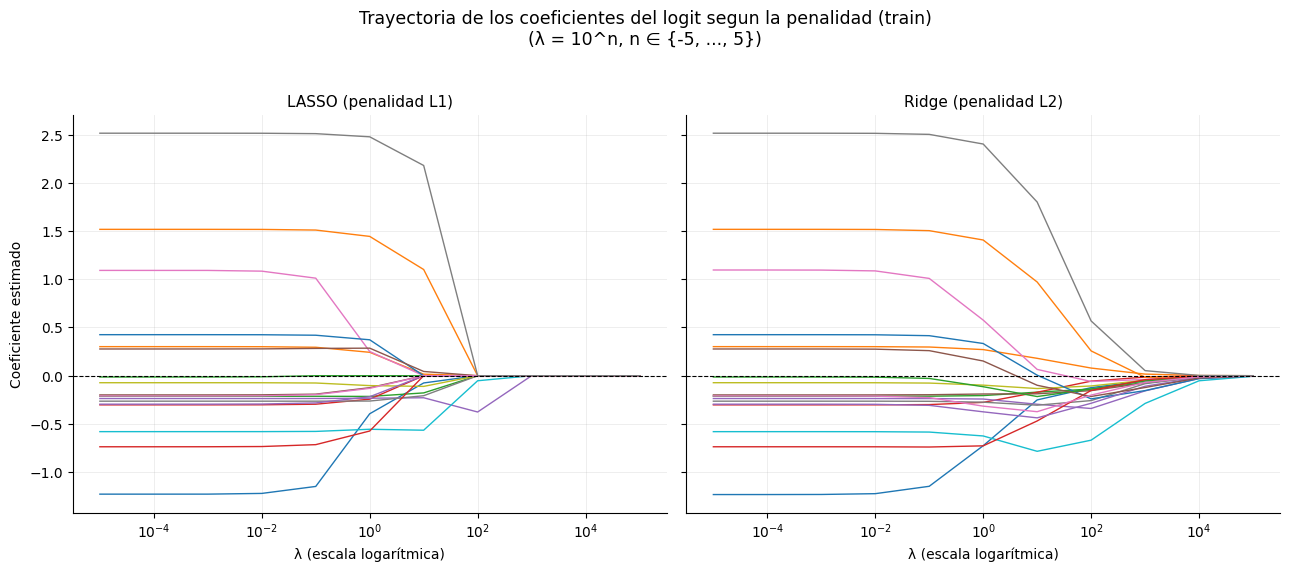

Variables con coeficiente exactamente 0 (LASSO), por lambda:
0.00001          0
0.00010          0
0.00100          0
0.01000          0
0.10000          1
1.00000          1
10.00000         8
100.00000       16
1000.00000      18
10000.00000     18
100000.00000    18
dtype: int64


In [11]:
#%% A.1. Visualizacion de la penalidad de LASSO y Ridge en funcion de lambda:

"""
A diferencia del TP3, aca no se vuelve a partir la base entre 2024 y
2025: todo el TP4 trabaja sobre 'ocupados_X_2025_MM' (regresores) y
'y_2025_MM_final' (variable dependiente, informalidad en 2025), que ya
quedaron armadas y alineadas en el TP3, incluyendo el rezago
'informal_2024_Informal', lo cual es consistente con el trabajo de
Maurizio & Monsalvo (2021).

CORRECCION METODOLOGICA: el path de coeficientes de A.1 se estima
sobre X_train / y_train unicamente, y no sobre la base completa. El
motivo es preservar la integridad del test: si el test se usara aca
(aunque sea solo para un grafico descriptivo), cualquier decision
posterior que se tome "mirando" ese grafico (por ejemplo, intuir en
que rango de lambda conviene buscar) estaria contaminada por haber
observado el comportamiento del modelo en datos que se supone deberian
permanecer no vistos hasta C.1.

El objetivo de A.1 sigue siendo puramente descriptivo: mostrar como se
mueve cada coeficiente del logit a medida que aumenta la penalidad,
para las dos tecnicas de regularizacion. Todavia no se elige ningun
lambda optimo (eso es A.2); aca solo se grafica la trayectoria
completa, ahora sobre el conjunto de entrenamiento.
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# A.1.1. Definir la grilla de penalidad:
"""
El enunciado parte de un lambda = 10^n con n en {-5,...,4,5}, es decir
11 valores que van de una penalidad casi nula (10^-5) a una penalidad
muy fuerte (10^5). 'LogisticRegression' de sklearn no recibe lambda
directamente: recibe 'C', que es la INVERSA de la fuerza de la
penalidad (C = 1/lambda). Por eso lambda se define primero, en la
escala requerida, y C se deriva de ahi solo para pasarselo al modelo.
"""

n_grid  = np.arange(-5, 6)      # n = -5, -4, ..., 4, 5 (11 valores)
lambdas = 10.0 ** n_grid        # lambda = 10^n
Cs      = 1 / lambdas           # C = 1/lambda, el parametro que usa sklearn

print("Grilla de lambda:", lambdas)

# A.1.2. Variables de trabajo:
"""
'X' e 'y' se redefinen aca como alias de 'X_train' / 'y_train', de
manera que el resto del codigo de A.1 (y de A.2/A.3, que reutilizan
estos mismos nombres) opere siempre sobre el conjunto de entrenamiento
sin necesidad de renombrar cada bloque. No se incluye la columna
'const': sklearn agrega su propio intercepto internamente
(fit_intercept = True por default).
"""

X = X_train.copy()
y = y_train.copy()

variables = X.columns.tolist()
print("Cantidad de regresores en X (train):", len(variables))

# A.1.3. Estimar un logit penalizado por cada lambda, para LASSO y Ridge,
# usando SOLO el conjunto de entrenamiento:
"""
Se recorre la grilla dos veces: una con penalty = 'l1' (LASSO) y otra
con penalty = 'l2' (Ridge), guardando en cada vuelta el vector completo
de coeficientes. El resultado son dos tablas (coef_lasso, coef_ridge)
de forma [variables x lambdas], que es la estructura que despues se
grafica.

'solver = liblinear' soporta tanto L1 como L2 y es adecuado para bases
de tamano moderado; si la matriz de regresores fuera mucho mas grande,
conviene reemplazarlo por 'saga'.
"""

coef_lasso = pd.DataFrame(index = variables, columns = lambdas, dtype = float)
coef_ridge = pd.DataFrame(index = variables, columns = lambdas, dtype = float)

for lam, C in zip(lambdas, Cs):

    modelo_l1 = LogisticRegression(
        penalty  = 'l1',
        C        = C,
        solver   = 'liblinear',
        max_iter = 5000
    ).fit(X, y)
    coef_lasso[lam] = modelo_l1.coef_.flatten()

    modelo_l2 = LogisticRegression(
        penalty  = 'l2',
        C        = C,
        solver   = 'liblinear',
        max_iter = 5000
    ).fit(X, y)
    coef_ridge[lam] = modelo_l2.coef_.flatten()

print("Coeficientes LASSO (primeras variables, todas las lambdas):")
print(coef_lasso.head().round(4))

# A.1.4. Grafico de dos paneles: trayectoria de coeficientes vs. lambda:
"""
Un panel por tecnica, una linea por variable dentro de cada panel. El
eje x va en escala logaritmica porque lambda crece en potencias de 10
(en escala lineal, los primeros valores quedarian todos amontonados
contra el origen).

Interpretacion esperada al mirar el grafico:
- Panel LASSO: las lineas se van "clavando" en cero de a una a medida
  que lambda crece -> LASSO hace seleccion de variables.
- Panel Ridge: las lineas se achican todas de forma gradual y pareja,
  pero ninguna llega exactamente a cero -> Ridge encoge, no selecciona.

Al estar estimado sobre train (75% de los datos originales), es
esperable que las trayectorias sean cualitativamente muy similares a
las que se obtendrian con la base completa, pero con leves diferencias
numericas por tener menos observaciones.
"""

fig, axes = plt.subplots(1, 2, figsize = (13, 5.5), sharey = True)

for var in variables:
    axes[0].plot(lambdas, coef_lasso.loc[var], linewidth = 1)
    axes[1].plot(lambdas, coef_ridge.loc[var], linewidth = 1)

axes[0].set_xscale('log')
axes[1].set_xscale('log')

axes[0].set_title('LASSO (penalidad L1)', fontsize = 11)
axes[1].set_title('Ridge (penalidad L2)', fontsize = 11)

for ax in axes:
    ax.set_xlabel('λ (escala logarítmica)')
    ax.axhline(0, color = 'black', linewidth = 0.8, linestyle = '--')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha = 0.25, linewidth = 0.6)

axes[0].set_ylabel('Coeficiente estimado')

fig.suptitle(
    'Trayectoria de los coeficientes del logit segun la penalidad (train)\n'
    '(λ = 10^n, n ∈ {-5, ..., 5})',
    fontsize = 12.5, y = 1.03
)

plt.tight_layout()
plt.savefig("A1_path_coeficientes.png", dpi = 300, bbox_inches = 'tight')
plt.show()

# A.1.5. Conteo de coeficientes exactamente en cero por lambda (LASSO):
"""
Cuantifica lo que se ve en el panel izquierdo: a medida que lambda
crece, mas coeficientes de LASSO quedan en cero exacto. Este resultado
se retoma en A.2 (proporcion de variables ignoradas) y en B.2 (cruce
con la importancia de variables del arbol).
"""

ceros_por_lambda = (coef_lasso == 0).sum()
print("Variables con coeficiente exactamente 0 (LASSO), por lambda:")
print(ceros_por_lambda)

## A.2 Penalidad óptima por Cross-validation y visualización

Grilla de lambda (misma que A.1): [1.e-05 1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02 1.e+03 1.e+04
 1.e+05]
Lambda_cv elegido por LASSO (L1), sobre train: 0.0001
Lambda_cv elegido por Ridge (L2), sobre train: 1e-05
Error de clasificacion por fold y lambda (LASSO, dentro de train):
   0.00001       0.00010       0.00100       0.01000       0.10000       \
0        0.0968        0.0946        0.0946        0.0946        0.0968   
1        0.0856        0.0856        0.0856        0.0856        0.0856   
2        0.0790        0.0790        0.0790        0.0790        0.0790   
3        0.0677        0.0677        0.0677        0.0677        0.0700   
4        0.0700        0.0700        0.0700        0.0700        0.0700   

   1.00000       10.00000      100.00000     1000.00000    10000.00000   \
0        0.0878        0.0833        0.1081        0.1081        0.1081   
1        0.0901        0.0923        0.1081        0.1081        0.1081   
2        0.0835        0.0790       

/tmp/ipykernel_1016/1380472978.py:129: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
/tmp/ipykernel_1016/1380472978.py:135: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


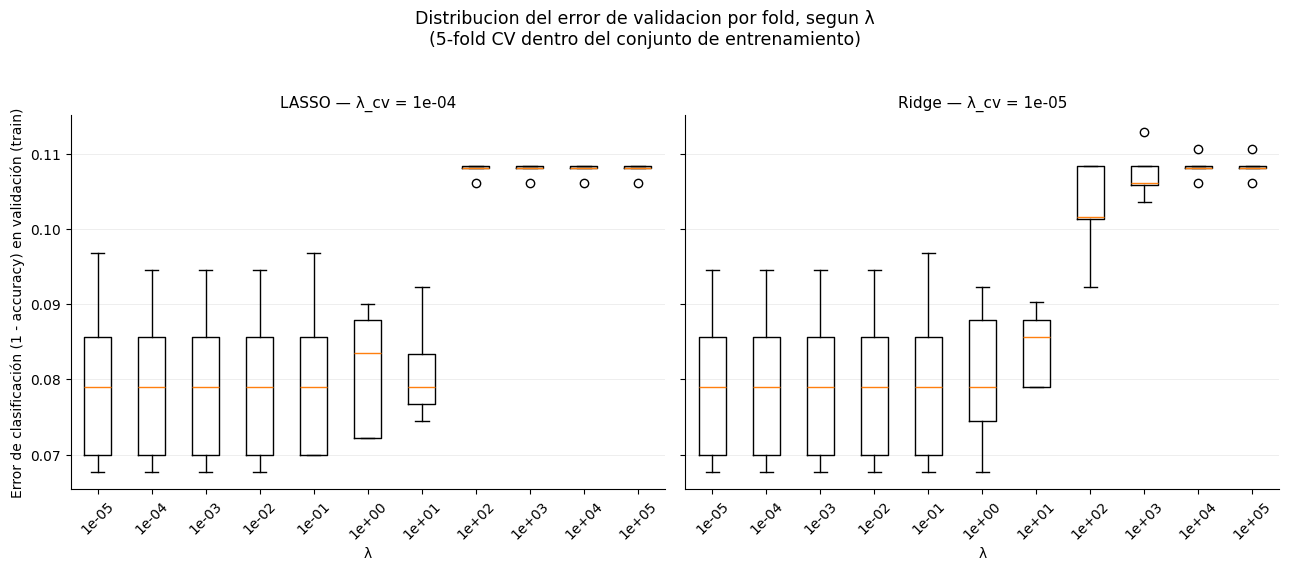

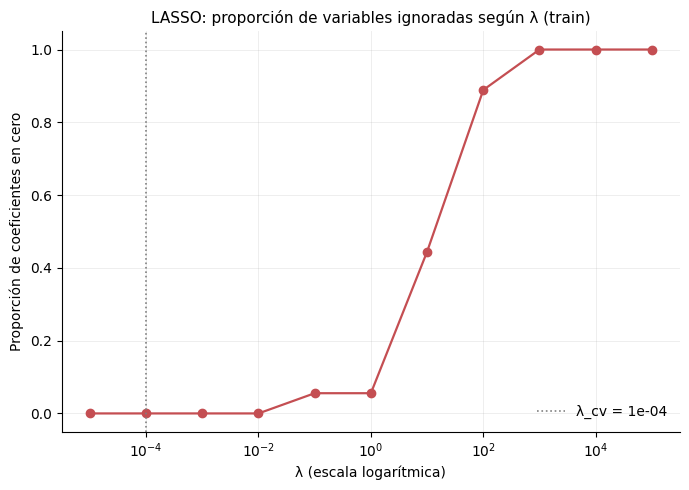

In [12]:
#%% A.2. Eleccion de la penalidad optima por Cross-Validation (5-fold),
#        usando UNICAMENTE el conjunto de entrenamiento:

"""
En A.1 se recorrio la grilla de lambda solo para observar la
trayectoria de los coeficientes, sin ningun criterio de "mejor" o
"peor", y ya sobre X_train/y_train (no la base completa). En A.2 se
agrega ese criterio: para cada lambda de la misma grilla, se mide que
tan bien predice el modelo en datos que NO uso para entrenar, usando
5-fold cross-validation DENTRO de train.

Esto significa que el 5-fold CV parte train en 5 sub-folds (cada uno
un 20% de train, es decir un 15% de la base original aproximadamente),
y rota cual de esos sub-folds queda "afuera" en cada ronda. El
resultado es que 'lambda_cv' se elige mirando unicamente informacion de
train: el conjunto de test (X_test / y_test, apartado en A.0) NO
interviene en ningun momento de este proceso, y se mantiene reservado
para la evaluacion final de C.1.

Esto se hace una vez para LASSO y otra vez para Ridge, por lo que se
obtienen dos lambda_cv distintos (no necesariamente coinciden).

'LogisticRegressionCV' hace todo el proceso de CV internamente y
ademas guarda, en el atributo 'scores_', el score de CADA fold para
CADA valor de C evaluado. Eso es lo que permite despues armar los
boxplots (una caja por lambda, con los 5 valores de error de sus 5
folds). El 'refit = True' (default) reestima el modelo final sobre
TODO train (no sobre la base completa) usando el mejor C encontrado.
"""

from sklearn.linear_model import LogisticRegressionCV

# A.2.1. Reutilizar la misma grilla de lambda/C de A.1, para que ambos
# puntos sean comparables:
print("Grilla de lambda (misma que A.1):", lambdas)

# A.2.2. Estimar LogisticRegressionCV para LASSO (L1), sobre train:
"""
'cv = 5' reparte X_train/y_train en 5 folds. 'scoring = accuracy' es
el criterio con el que se compara cada fold (accuracy = 1 - error de
clasificacion).
"""

cv_lasso = LogisticRegressionCV(
    Cs       = Cs,
    cv       = 5,
    penalty  = 'l1',
    solver   = 'liblinear',
    scoring  = 'accuracy',
    max_iter = 5000,
    refit    = True
).fit(X, y)   # X, y = X_train, y_train (definidos en A.1.2)

# A.2.3. Estimar LogisticRegressionCV para Ridge (L2), sobre train:
cv_ridge = LogisticRegressionCV(
    Cs       = Cs,
    cv       = 5,
    penalty  = 'l2',
    solver   = 'liblinear',
    scoring  = 'accuracy',
    max_iter = 5000,
    refit    = True
).fit(X, y)

# A.2.4. Recuperar el lambda_cv elegido por cada tecnica:
"""
'.C_' devuelve el mejor C encontrado (uno por clase; en un problema
binario es un solo valor). Se convierte a lambda invirtiendo la
relacion C = 1/lambda.
"""

C_cv_lasso = cv_lasso.C_[0]
C_cv_ridge = cv_ridge.C_[0]

lambda_cv_lasso = 1 / C_cv_lasso
lambda_cv_ridge = 1 / C_cv_ridge

print("Lambda_cv elegido por LASSO (L1), sobre train:", lambda_cv_lasso)
print("Lambda_cv elegido por Ridge (L2), sobre train:", lambda_cv_ridge)

# A.2.5. Extraer el error de validacion por fold y por lambda, para los boxplots:
"""
'.scores_' es un diccionario {clase: matriz}. En un problema binario
tiene una sola clave. La matriz tiene forma (n_folds, n_lambdas), es
decir: 5 filas (una por fold DENTRO de train) y 11 columnas (una por
lambda de la grilla). Se transforma en error = 1 - accuracy, porque el
enunciado pide "error de prediccion" y no accuracy.

IMPORTANTE: 'cv_lasso.Cs_' devuelve el orden REAL en que quedaron las
columnas (no siempre coincide con el orden en que se paso 'Cs'), asi
que las lambdas de las columnas se reconstruyen a partir de 'Cs_' y no
de la grilla original, para que cada columna quede etiquetada con el
lambda que realmente le corresponde.
"""

clase_lasso = list(cv_lasso.scores_.keys())[0]
clase_ridge = list(cv_ridge.scores_.keys())[0]

accuracy_folds_lasso = cv_lasso.scores_[clase_lasso]   # (5, 11)
accuracy_folds_ridge = cv_ridge.scores_[clase_ridge]   # (5, 11)

error_folds_lasso = 1 - accuracy_folds_lasso
error_folds_ridge = 1 - accuracy_folds_ridge

lambdas_lasso_cols = 1 / cv_lasso.Cs_
lambdas_ridge_cols = 1 / cv_ridge.Cs_

df_error_lasso = pd.DataFrame(error_folds_lasso, columns = lambdas_lasso_cols)
df_error_ridge = pd.DataFrame(error_folds_ridge, columns = lambdas_ridge_cols)

print("Error de clasificacion por fold y lambda (LASSO, dentro de train):")
print(df_error_lasso.round(4))

# A.2.6. Boxplots del error de validacion, uno por lambda, para cada tecnica:
"""
Cada caja resume los 5 errores (uno por fold DENTRO de train) obtenidos
con ese lambda. Una caja angosta indica que el error es estable entre
folds; una caja ancha indica que el resultado depende mucho de que
datos cayeron en el fold de validacion. La linea vertical marca el
lambda_cv elegido por LogisticRegressionCV para esa tecnica.

Estos boxplots NO incluyen ninguna informacion de X_test/y_test: son
puramente el resultado de rotar folds dentro del conjunto de
entrenamiento.
"""

fig, axes = plt.subplots(1, 2, figsize = (13, 5.5), sharey = True)

axes[0].boxplot(
    [df_error_lasso[col] for col in df_error_lasso.columns],
    labels = [f"{lam:.0e}" for lam in df_error_lasso.columns]
)
axes[0].set_title(f'LASSO — λ_cv = {lambda_cv_lasso:.0e}', fontsize = 11)

axes[1].boxplot(
    [df_error_ridge[col] for col in df_error_ridge.columns],
    labels = [f"{lam:.0e}" for lam in df_error_ridge.columns]
)
axes[1].set_title(f'Ridge — λ_cv = {lambda_cv_ridge:.0e}', fontsize = 11)

for ax in axes:
    ax.set_xlabel('λ')
    ax.tick_params(axis = 'x', rotation = 45)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis = 'y', alpha = 0.25, linewidth = 0.6)

axes[0].set_ylabel('Error de clasificación (1 - accuracy) en validación (train)')

fig.suptitle(
    'Distribucion del error de validacion por fold, segun λ\n'
    '(5-fold CV dentro del conjunto de entrenamiento)',
    fontsize = 12.5, y = 1.03
)

plt.tight_layout()
plt.savefig("A2_boxplots_error_cv.png", dpi = 300, bbox_inches = 'tight')
plt.show()

# A.2.7. (Opcional) Proporcion de variables ignoradas por LASSO, en funcion de lambda:
"""
Reutiliza la tabla 'coef_lasso' calculada en A.1 (coeficientes de un
logit L1 estimado sobre TRAIN, para cada lambda de la grilla): para
cada lambda, que porcentaje de los coeficientes quedo exactamente en
cero. Es un grafico de puntos conectados, complementario al panel
izquierdo de A.1 pero expresado en un solo numero por lambda.
"""

proporcion_cero = (coef_lasso == 0).mean()   # promedio de una serie de 0/1 = proporcion

fig, ax = plt.subplots(figsize = (7, 5))
ax.plot(proporcion_cero.index, proporcion_cero.values,
        marker = 'o', color = '#C44E52', linewidth = 1.6)
ax.axvline(lambda_cv_lasso, color = 'grey', linestyle = ':', linewidth = 1.2,
           label = f'λ_cv = {lambda_cv_lasso:.0e}')
ax.set_xscale('log')
ax.set_xlabel('λ (escala logarítmica)')
ax.set_ylabel('Proporción de coeficientes en cero')
ax.set_title('LASSO: proporción de variables ignoradas según λ (train)', fontsize = 11)
ax.legend(frameon = False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha = 0.25, linewidth = 0.6)

plt.tight_layout()
plt.savefig("A2_proporcion_variables_cero.png", dpi = 300, bbox_inches = 'tight')
plt.show()

## A.3 Estimación con 𝜆𝑐𝑣 y comparación de coeficientes

In [13]:
#%% A.3. Estimacion final con lambda_cv: dos versiones con roles distintos.

"""
Siguiendo el esquema acordado:

(1) Se estiman los tres modelos SOBRE TRAIN. Estos son los modelos que
    en C.1 se van a evaluar prediciendo sobre X_test, para confirmar
    que el lambda_cv elegido en A.2 efectivamente generaliza bien a
    datos nunca vistos.

(2) Una vez que esa validacion este hecha (o programada para C.1), se
    reestiman los mismos tres modelos, con el MISMO lambda_cv, pero
    sobre la base COMPLETA (train + test). Esta segunda version es la
    que se usa para la tabla de coeficientes y EMP que se reporta e
    interpreta en el informe -- mas datos, coeficientes mas precisos,
    sin comprometer la validacion (que ya se hizo con la version de
    train).
"""

# ============================================================
# PARTE 1: modelos sobre TRAIN (para validar en C.1)
# ============================================================

# A.3.1. Logit sin penalidad, sobre train:
modelo_sin_penalidad = LogisticRegression(
    penalty  = None,
    solver   = 'lbfgs',
    max_iter = 5000
).fit(X_train, y_train)

coef_sin_penalidad = pd.Series(
    modelo_sin_penalidad.coef_.flatten(), index = X_train.columns
)

# A.3.2. Logit con penalidad L1 (lambda_cv de LASSO), sobre train:
C_lasso_final = 1 / lambda_cv_lasso

modelo_l1_final = LogisticRegression(
    penalty  = 'l1',
    C        = C_lasso_final,
    solver   = 'liblinear',
    max_iter = 5000
).fit(X_train, y_train)

coef_l1_final = pd.Series(
    modelo_l1_final.coef_.flatten(), index = X_train.columns
)

# A.3.3. Logit con penalidad L2 (lambda_cv de Ridge), sobre train:
C_ridge_final = 1 / lambda_cv_ridge

modelo_l2_final = LogisticRegression(
    penalty  = 'l2',
    C        = C_ridge_final,
    solver   = 'liblinear',
    max_iter = 5000
).fit(X_train, y_train)

coef_l2_final = pd.Series(
    modelo_l2_final.coef_.flatten(), index = X_train.columns
)

print("Modelos sobre TRAIN estimados: 'modelo_sin_penalidad', "
      "'modelo_l1_final', 'modelo_l2_final'.")
print("Estos se reutilizan en C.1 para predecir sobre X_test.")

Modelos sobre TRAIN estimados: 'modelo_sin_penalidad', 'modelo_l1_final', 'modelo_l2_final'.
Estos se reutilizan en C.1 para predecir sobre X_test.


A.3.1 EMP de los modelos sobre TRAIN

In [14]:
# ============================================================
# PARTE 2: EMP de los modelos sobre TRAIN
# (se usan solo como chequeo intermedio; los definitivos son los de
# la base completa, mas abajo)
# ============================================================

cols_continuas = [c for c in continuas if c in X_train.columns]
cols_dummies   = [c for c in X_train.columns if c not in cols_continuas]

def calcular_emp(modelo, X):
    """
    Devuelve una Serie con el EMP de cada variable de X, para el
    'modelo' de sklearn ya entrenado (LogisticRegression), evaluado
    sobre la muestra X.

    - Continuas: formula analitica p*(1-p)*beta, promediada sobre
      toda la muestra ("at overall").
    - Dummies: cambio discreto, prediciendo con la dummy en 1 para
      todos vs. en 0 para todos, y promediando la diferencia.
    """
    beta  = pd.Series(modelo.coef_.flatten(), index = X.columns)
    p_hat = modelo.predict_proba(X)[:, 1]

    emp = {}

    factor_promedio = np.mean(p_hat * (1 - p_hat))
    for var in cols_continuas:
        emp[var] = factor_promedio * beta[var]

    for var in cols_dummies:
        X_1 = X.copy(); X_1[var] = 1
        X_0 = X.copy(); X_0[var] = 0
        p_1 = modelo.predict_proba(X_1)[:, 1]
        p_0 = modelo.predict_proba(X_0)[:, 1]
        emp[var] = np.mean(p_1 - p_0)

    return pd.Series(emp).reindex(X.columns)

A.3.2 EMP de BASE COMPLETA

In [15]:
# ============================================================
# PARTE 3: reestimacion sobre la BASE COMPLETA (para interpretacion)
# ============================================================

"""
Se reutiliza el mismo lambda_cv_lasso y lambda_cv_ridge ya elegidos en
A.2 (por CV sobre train): no se vuelve a buscar un lambda optimo con la
base completa, para no introducir un criterio de seleccion distinto
del que ya se valido.
"""

X_full = pd.concat([X_train, X_test], axis = 0)
y_full = pd.concat([y_train, y_test], axis = 0)

print("Observaciones en la base completa:", X_full.shape[0],
      "(train:", X_train.shape[0], "+ test:", X_test.shape[0], ")")

modelo_sin_penalidad_full = LogisticRegression(
    penalty  = None,
    solver   = 'lbfgs',
    max_iter = 5000
).fit(X_full, y_full)

modelo_l1_final_full = LogisticRegression(
    penalty  = 'l1',
    C        = C_lasso_final,
    solver   = 'liblinear',
    max_iter = 5000
).fit(X_full, y_full)

modelo_l2_final_full = LogisticRegression(
    penalty  = 'l2',
    C        = C_ridge_final,
    solver   = 'liblinear',
    max_iter = 5000
).fit(X_full, y_full)

coef_sin_penalidad_full = pd.Series(
    modelo_sin_penalidad_full.coef_.flatten(), index = X_full.columns
)
coef_l1_final_full = pd.Series(
    modelo_l1_final_full.coef_.flatten(), index = X_full.columns
)
coef_l2_final_full = pd.Series(
    modelo_l2_final_full.coef_.flatten(), index = X_full.columns
)

# A.3.4. Tabla de coeficientes DEFINITIVA (base completa), la que va al informe:
tabla_coef_regularizacion = pd.DataFrame({
    'Sin penalidad':                         coef_sin_penalidad_full,
    f'LASSO (λ_cv = {lambda_cv_lasso:.0e})': coef_l1_final_full,
    f'Ridge (λ_cv = {lambda_cv_ridge:.0e})': coef_l2_final_full,
})
tabla_coef_regularizacion.index.name = 'Variable'

print("Tabla de coeficientes (base completa, para el informe):")
print(tabla_coef_regularizacion.round(4).to_string())

# A.3.5. Metricas de resumen (shrinkage y cantidad de ceros), base completa:
resumen_shrinkage = pd.DataFrame({
    'Magnitud promedio |coef|': [
        coef_sin_penalidad_full.abs().mean(),
        coef_l1_final_full.abs().mean(),
        coef_l2_final_full.abs().mean(),
    ],
    'Cantidad de coef. = 0': [
        int((coef_sin_penalidad_full == 0).sum()),
        int((coef_l1_final_full == 0).sum()),
        int((coef_l2_final_full == 0).sum()),
    ],
}, index = ['Sin penalidad', 'LASSO', 'Ridge'])

print(resumen_shrinkage.round(4))

variables_eliminadas_lasso = coef_l1_final_full[coef_l1_final_full == 0].index.tolist()
print("Variables eliminadas por LASSO (coef = 0):", variables_eliminadas_lasso)
print("Cantidad eliminada:", len(variables_eliminadas_lasso), "de", len(X_full.columns))

# A.3.6. EMP DEFINITIVOS (base completa):
emp_sin_penalidad = calcular_emp(modelo_sin_penalidad_full, X_full)
emp_lasso         = calcular_emp(modelo_l1_final_full,      X_full)
emp_ridge         = calcular_emp(modelo_l2_final_full,      X_full)

tabla_emp_completa = pd.DataFrame({
    'Coef. Sin penalidad': coef_sin_penalidad_full,
    'EMP Sin penalidad':   emp_sin_penalidad,
    'Coef. LASSO':         coef_l1_final_full,
    'EMP LASSO':           emp_lasso,
    'Coef. Ridge':         coef_l2_final_full,
    'EMP Ridge':           emp_ridge,
})
tabla_emp_completa.index.name = 'Variable'

print("Tabla de EMP (base completa, para el informe):")
print(tabla_emp_completa.round(4).to_string())

resumen_emp = pd.DataFrame({
    'Magnitud promedio |EMP|': [
        emp_sin_penalidad.abs().mean(),
        emp_lasso.abs().mean(),
        emp_ridge.abs().mean(),
    ],
}, index = ['Sin penalidad', 'LASSO', 'Ridge'])

print(resumen_emp.round(4))

# A.3.7. Exportar todo a Excel:
tabla_coef_regularizacion.to_excel(
    "A3_tabla_coeficientes.xlsx", sheet_name = "Coef_comparacion", float_format = "%.4f"
)
resumen_shrinkage.to_excel(
    "A3_resumen_shrinkage.xlsx", sheet_name = "Resumen", float_format = "%.4f"
)
tabla_emp_completa.to_excel(
    "A3_tabla_EMP.xlsx", sheet_name = "EMP_3_modelos", float_format = "%.4f"
)
resumen_emp.to_excel(
    "A3_resumen_EMP.xlsx", sheet_name = "Resumen_EMP", float_format = "%.4f"
)

Observaciones en la base completa: 2956 (train: 2217 + test: 739 )
Tabla de coeficientes (base completa, para el informe):
                              Sin penalidad  LASSO (λ_cv = 1e-04)  Ridge (λ_cv = 1e-05)
Variable                                                                               
edad                                -1.5225               -1.5496               -1.5524
cant_ocupaciones_ad                  0.3046                0.3068                0.3068
horas_s_principal                   -0.2377               -0.2356               -0.2356
horas_s_otras_act                   -0.2700               -0.2728               -0.2729
ingreso_total                       -0.1214               -0.1211               -0.1211
dummy_menor5                        -0.2531               -0.2594               -0.2596
edad2                                1.4699                1.4963                1.4991
educ                                -0.1736               -0.1728               -0.17

# Parte B: Árboles

## B.1. Estimación un árbol de decisión podado (CART) eligiendo el hiperparámetro de costo de complejidad del árbol:

B.1.1. Cross-validation (5-fold) sobre la grilla de alphas:

In [16]:
# Poda del árbol por costo de complejidad (ccp_alpha) con 5-fold CV:

"""
Se sigue la misma lógica de A.0-A.3: todo el proceso de seleccion de
hiperparametros se hace UNICAMENTE sobre X_train / y_train. El test
(X_test / y_test) se mantiene reservado para C.1.

Para obtener la grilla de ccp_alpha se usa
'cost_complexity_pruning_path', que devuelve los valores de alpha que
efectivamente generan un cambio en la poda del arbol (a diferencia de
una grilla arbitraria como en A.1 para LASSO/Ridge, aca la grilla la
determina la propia estructura del arbol entrenado sobre train).
"""

# Árbol sin podar, solo para extraer el camino de poda:
arbol_completo = DecisionTreeClassifier(random_state = RANDOM_STATE)
path = arbol_completo.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
impurities = path.impurities

# Se descarta el último alpha (corresponde al arbol reducido a un solo
# nodo, sin valor practico para comparar):
ccp_alphas = ccp_alphas[:-1]

print("Cantidad de valores de ccp_alpha en la grilla:", len(ccp_alphas))
print("Rango de ccp_alpha: [", ccp_alphas.min(), ",", ccp_alphas.max(), "]")

# Grilla final:
# ccp_alphas_final = ccp_alphas
ccp_alphas_final = np.linspace(0, 0.004941402668942822, 50)
display(ccp_alphas_final)

Cantidad de valores de ccp_alpha en la grilla: 77
Rango de ccp_alpha: [ 0.0 , 0.004941402668942822 ]


array([0.        , 0.00010084, 0.00020169, 0.00030253, 0.00040338,
       0.00050422, 0.00060507, 0.00070591, 0.00080676, 0.0009076 ,
       0.00100845, 0.00110929, 0.00121014, 0.00131098, 0.00141183,
       0.00151267, 0.00161352, 0.00171436, 0.00181521, 0.00191605,
       0.0020169 , 0.00211774, 0.00221859, 0.00231943, 0.00242028,
       0.00252112, 0.00262197, 0.00272281, 0.00282366, 0.0029245 ,
       0.00302535, 0.00312619, 0.00322704, 0.00332788, 0.00342873,
       0.00352957, 0.00363042, 0.00373126, 0.00383211, 0.00393295,
       0.0040338 , 0.00413464, 0.00423549, 0.00433633, 0.00443718,
       0.00453802, 0.00463887, 0.00473971, 0.00484056, 0.0049414 ])

B.1.2. Cross-validation (5-fold) sobre la grilla de alphas:

In [17]:
# Para cada ccp_alpha de la grilla, medir el error de
# clasificacion promedio en 5-fold CV, usando SOLO train:
"""
'cross_val_score' con 'scoring = accuracy' devuelve el accuracy de
cada uno de los 5 folds. El error de clasificacion es 1 - accuracy,
consistente con la definicion usada en la Parte A (C.1) y con el
enunciado del TP.
"""

errores_cv_arbol = []
errores_std_arbol = []

for alpha in ccp_alphas_final:
    modelo = DecisionTreeClassifier(ccp_alpha = alpha, random_state = RANDOM_STATE)
    scores = cross_val_score(modelo, X_train, y_train, cv = 5, scoring = 'accuracy')

    error_promedio = 1 - scores.mean()
    errores_cv_arbol.append(error_promedio)
    errores_std_arbol.append(scores.std())

errores_cv_arbol = np.array(errores_cv_arbol)
errores_std_arbol = np.array(errores_std_arbol)

# Mostrar los valores de los errores:
print('Valores de accuracy:')
display(errores_cv_arbol)

print('\nDesviación estándar del accuracy:')
display(errores_std_arbol)

Valores de accuracy:


array([0.11592337, 0.11592337, 0.11592337, 0.11502145, 0.11141073,
       0.10780611, 0.1005867 , 0.10013625, 0.0933673 , 0.09246334,
       0.09517113, 0.08976064, 0.08931222, 0.08796189, 0.08615602,
       0.08480264, 0.08525105, 0.08886076, 0.08705489, 0.08705387,
       0.08705387, 0.08705387, 0.085248  , 0.085248  , 0.085248  ,
       0.085248  , 0.08569947, 0.08569947, 0.08569947, 0.08569947,
       0.08569947, 0.08569947, 0.08524902, 0.08524902, 0.08524902,
       0.08524902, 0.08524902, 0.08524902, 0.08524902, 0.08524902,
       0.08524902, 0.08524902, 0.08524902, 0.08524902, 0.08524902,
       0.08524902, 0.08524902, 0.08524902, 0.08975962, 0.08975962])


Desviación estándar del accuracy:


array([0.01281227, 0.01281227, 0.01281227, 0.01307942, 0.013259  ,
       0.01381134, 0.01182215, 0.0102598 , 0.00611847, 0.00722034,
       0.00999518, 0.00521212, 0.00841041, 0.00799492, 0.00827903,
       0.00817535, 0.00560744, 0.00649634, 0.00581092, 0.00543524,
       0.00484016, 0.00484016, 0.00497707, 0.00497707, 0.00497707,
       0.00497707, 0.00490179, 0.00490179, 0.00490179, 0.00490179,
       0.00490179, 0.00490179, 0.00538515, 0.00538515, 0.00538515,
       0.00538515, 0.00538515, 0.00538515, 0.00538515, 0.00538515,
       0.00538515, 0.00538515, 0.00538515, 0.00538515, 0.00538515,
       0.00538515, 0.00538515, 0.00538515, 0.00410492, 0.00410492])

B.1.3. Gráfico de línea: error de clasificación vs. ccp_alpha:

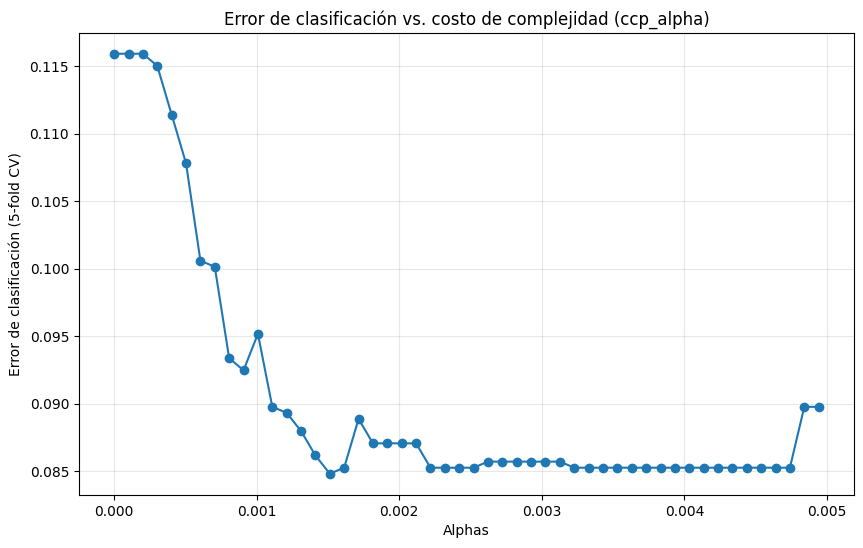

In [18]:
# Gráfico de línea del error de clasificación en función de la
# grilla de ccp_alpha (consigna B.1):
plt.figure(figsize = (10, 6))
plt.plot(ccp_alphas_final, errores_cv_arbol, marker = 'o')
plt.xlabel('Alphas')
plt.ylabel('Error de clasificación (5-fold CV)')
plt.title('Error de clasificación vs. costo de complejidad (ccp_alpha)')
plt.grid(alpha = 0.3)
plt.show()

B.1.4. Búsqueda del alpha adecuado:

In [19]:
tree_para = {'ccp_alpha':ccp_alphas_final, 'criterion':['gini']}
tree_cv = GridSearchCV(DecisionTreeClassifier(), tree_para, cv = 5, scoring = 'accuracy')
tree_cv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'ccp_alpha': array([0.        , 0.00010084, 0.00020169, 0.00030253, 0.00040338,
       0.00050422, 0.00060507, 0.00070591, 0.00080676, 0.0009076 ,
       0.00100845, 0.00110929, 0.00121014, 0.00131098, 0.00141183,
       0.00151267, 0.00161352, 0.00171436, 0.00181521, 0.00191605,
       0.0020169 , 0.00211774, 0.00221859, 0.00231943, 0.00242028,
       0.00252112, 0.00262197, 0.00272281, 0.00282366, 0.0029245 ,
       0.00302535, 0.00312619, 0.00322704, 0.00332788, 0.00342873,
       0.00352957, 0.00363042, 0.00373126, 0.00383211, 0.00393295,
       0.0040338 , 0.00413464, 0.00423549, 0.00433633, 0.00443718,
       0.00453802, 0.00463887, 0.00473971, 0.00484056, 0.0049414 ]),
                         'criterion': ['gini']},
             scoring='accuracy')

In [20]:
print("Best Parameters:", tree_cv.best_params_)
print("Best Accuracy Score:", tree_cv.best_score_.round(2))

Best Parameters: {'ccp_alpha': np.float64(0.001512674286411068), 'criterion': 'gini'}
Best Accuracy Score: 0.92


## B.2. Visualización del árbol:

B.2.1. Visualización del árbol de decisión:

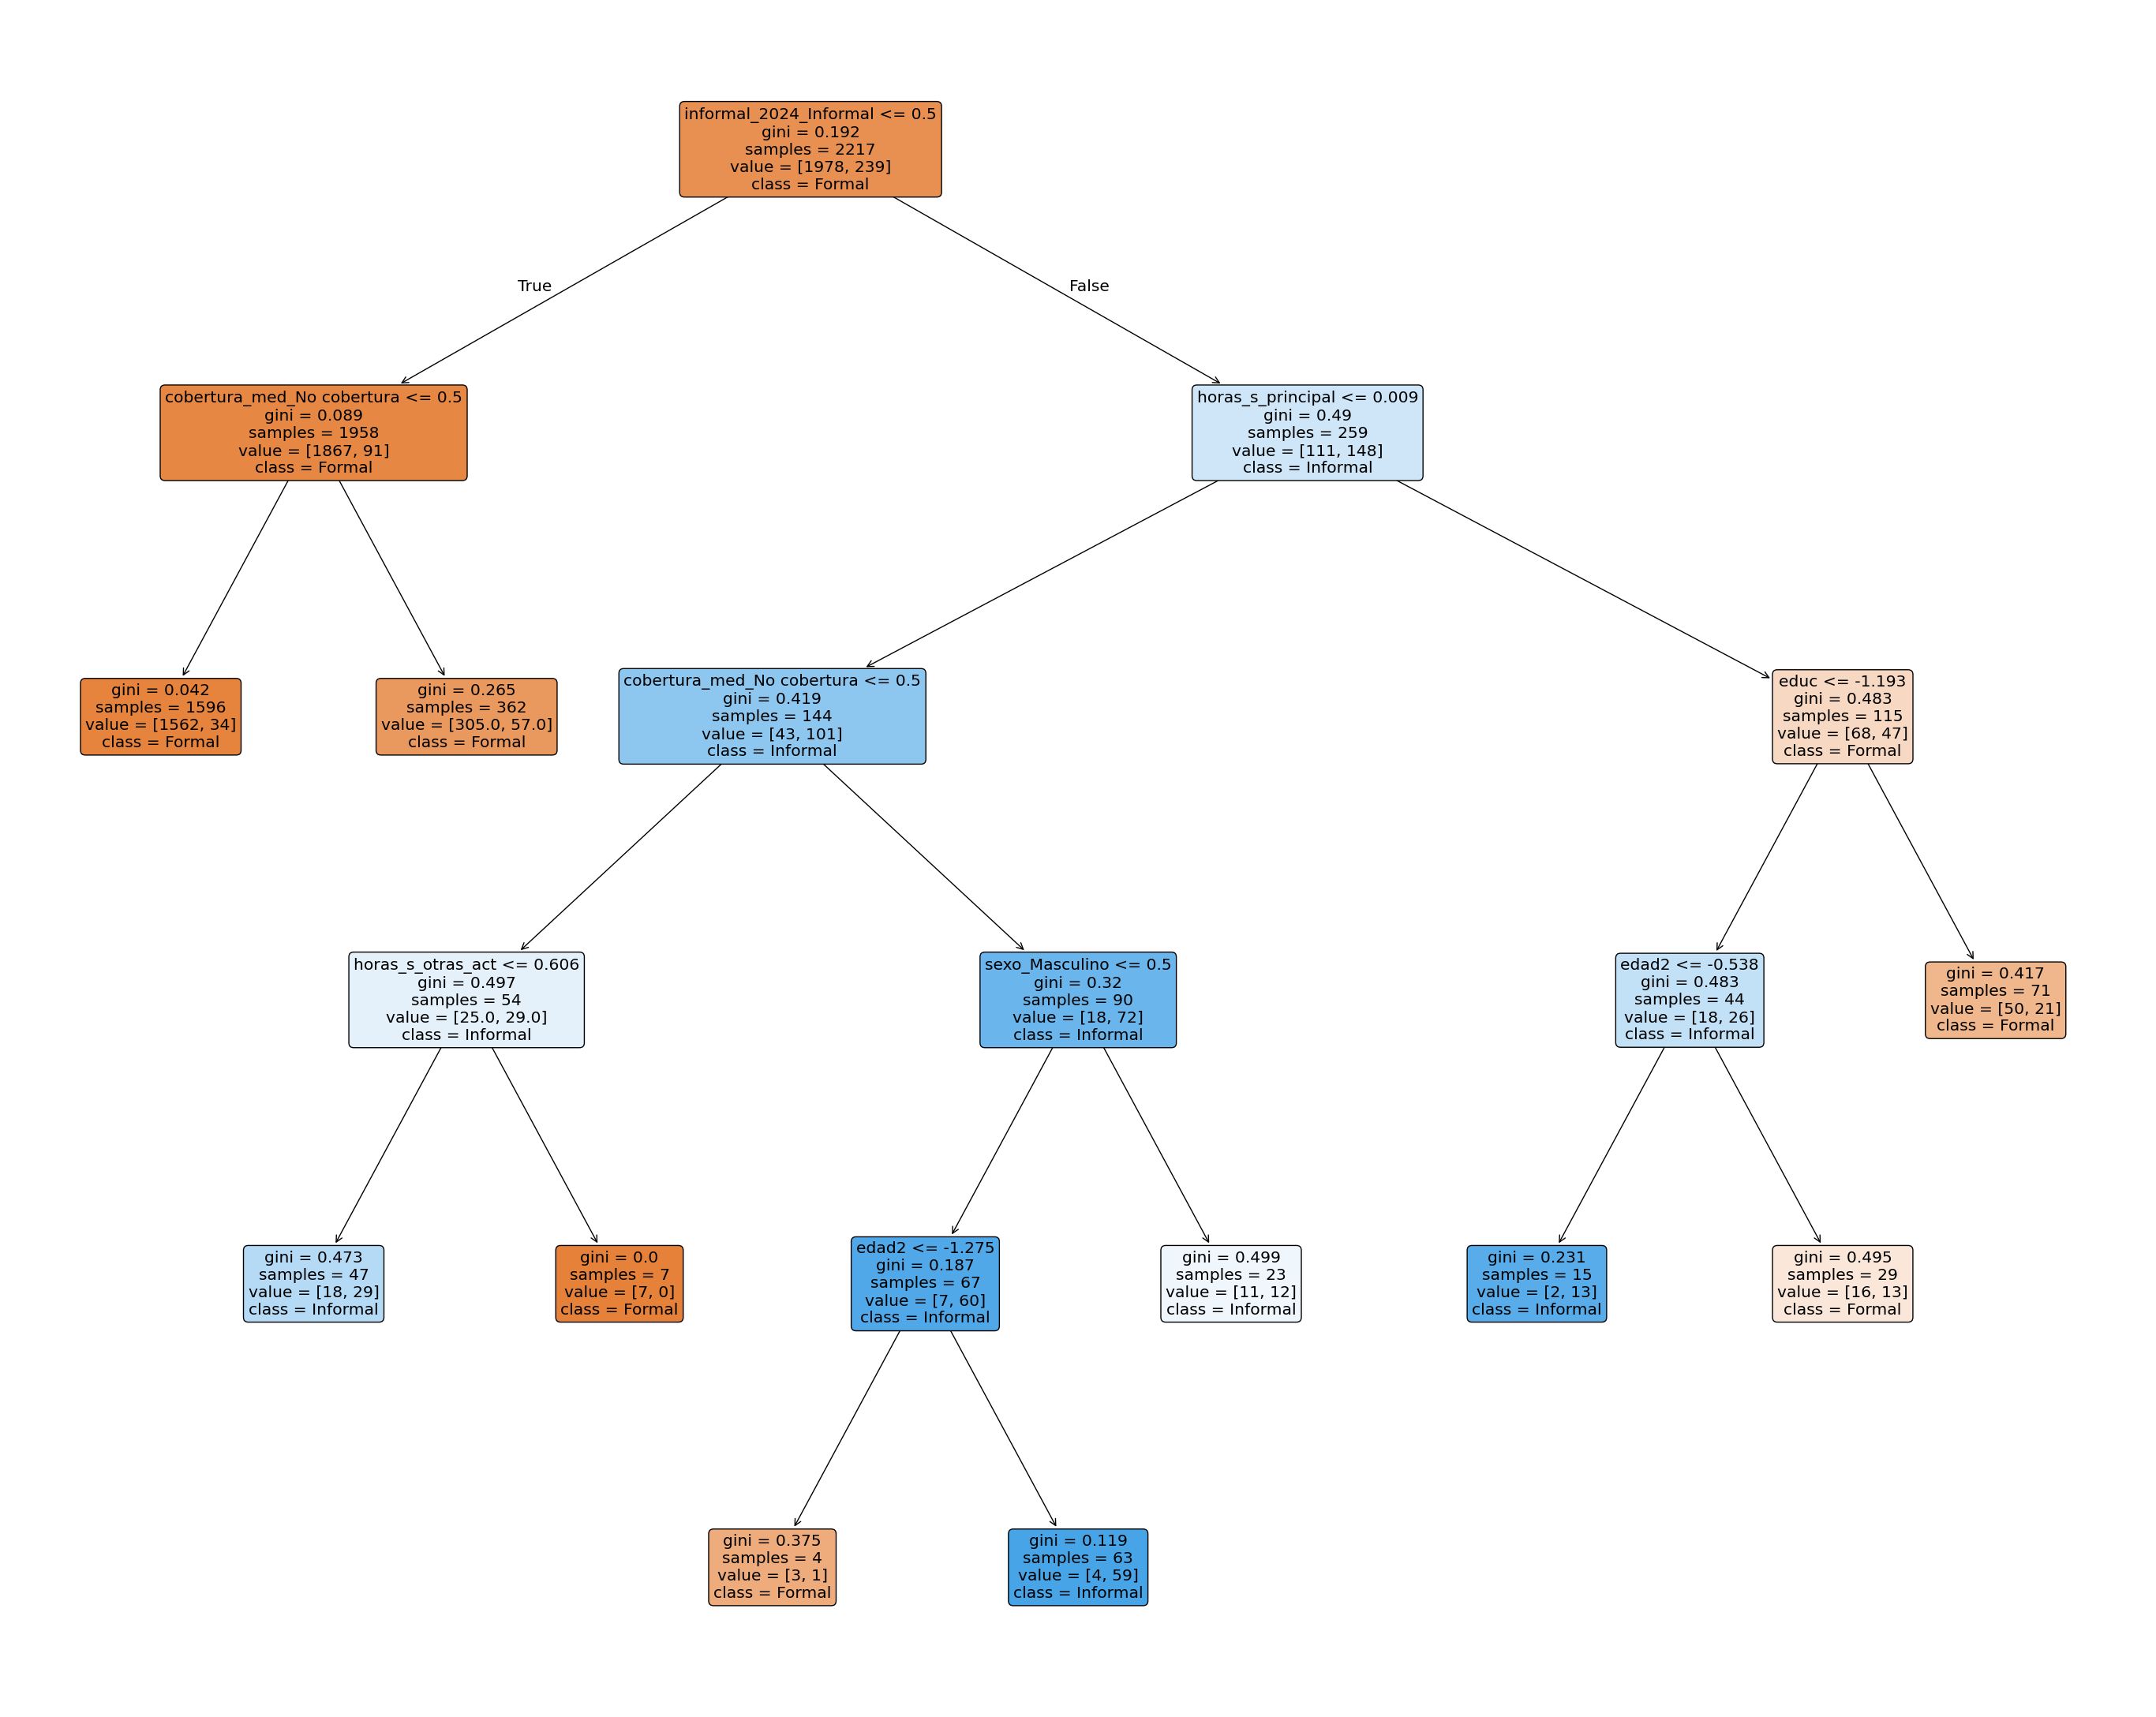

In [21]:
# Creamos un arbol:
decision_tree = DecisionTreeClassifier(ccp_alpha = tree_cv.best_params_['ccp_alpha']).fit(X_train, y_train)

# Gráfico
fig = plt.figure(figsize = (35, 28))
graph = plot_tree(decision_tree,
                  impurity = True,
                  feature_names = list(X_train.columns),
                  class_names = ['Formal', 'Informal'],
                  rounded = True,
                  filled = True)
fig.savefig("Tree_informal_cv_prunned.pdf", bbox_inches = 'tight')

B.2.2. Creación de etiquetas de las variables del gráfico de importancia de los predictores:

In [22]:
# Diccionario de etiquetas comprensibles para los predictores:

etiquetas = {
    # Rezago
    'informal_2024_Informal'       : 'Informal en 2024 (rezago)',
    # Cobertura médica
    'cobertura_med_No cobertura'   : 'Sin cobertura médica',
    # Horas trabajadas
    'horas_s_principal'            : 'Horas semanales (ocupación principal)',
    'horas_s_otras_act'            : 'Horas semanales (otras actividades)',
    # Características individuales
    'edad'                         : 'Edad',
    'edad2'                        : 'Edad al cuadrado',
    'sexo_Masculino'               : 'Sexo masculino',
    'educ'                         : 'Nivel educativo',
    'estado_civil_Sin pareja'      : 'Sin pareja',
    'dummy_menor5'                 : 'Tiene hijo menor de 5 años',
    'nhogar'                       : 'Tamaño del hogar',
    # Ingresos y ocupaciones
    'ingreso_total'                : 'Ingreso total',
    'cant_ocupaciones_ad'          : 'Cantidad de ocupaciones adicionales',
    # Región
    'region_cat_Gran Buenos Aires' : 'Gran Buenos Aires',
    'region_cat_Noreste'           : 'Región Noreste',
    'region_cat_Noroeste'          : 'Región Noroeste',
    'region_cat_Pampeana'          : 'Región Pampeana',
    'region_cat_Patagonia'         : 'Región Patagonia',
}

B.2.3. Creación del gráfico de importancia de los predictores del árbol de decisión:

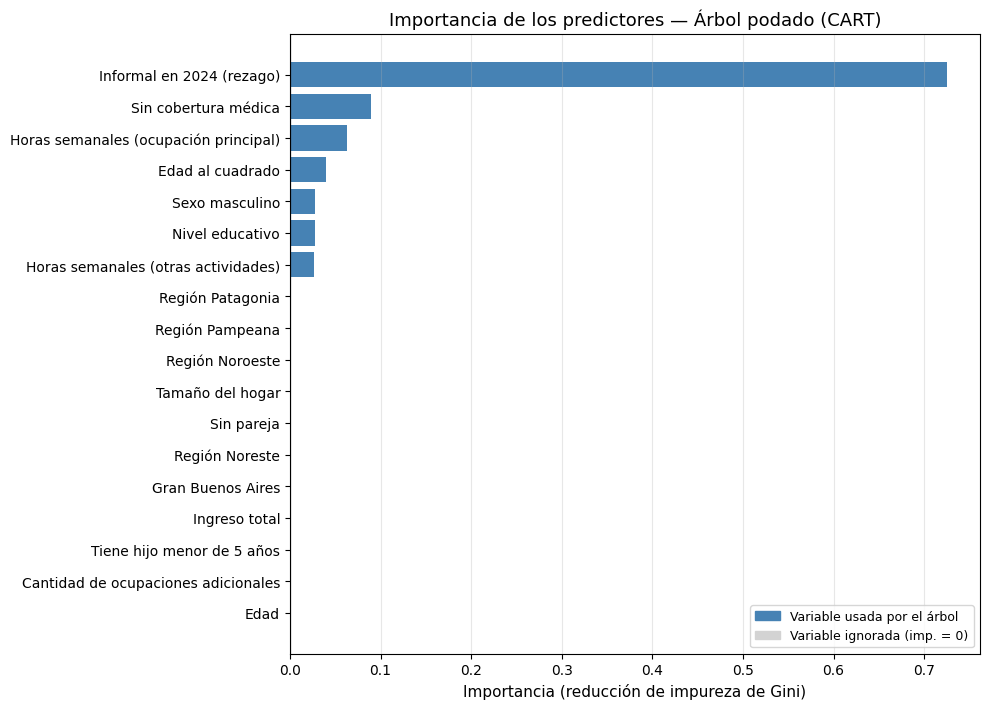

In [23]:
# Gráfico de importancia con etiquetas comprensibles:

# Construir Series de importancias con etiquetas legibles:
importancias = pd.Series(
    decision_tree.feature_importances_,
    index = X_train.columns
)

# Reemplazar nombres técnicos por etiquetas legibles:
# (los que no estén en el diccionario se mantienen tal cual):
importancias.index = [etiquetas.get(col, col) for col in importancias.index]
importancias       = importancias.sort_values(ascending=True)

colores = ['steelblue' if v > 0 else 'lightgrey' for v in importancias]

fig_imp, ax_imp = plt.subplots(figsize=(10, max(6, len(importancias) * 0.4)))

ax_imp.barh(importancias.index, importancias.values, color=colores)
ax_imp.axvline(x = 0, color = 'black', linewidth = 0.8)
ax_imp.set_xlabel('Importancia (reducción de impureza de Gini)', fontsize = 11)
ax_imp.set_title('Importancia de los predictores — Árbol podado (CART)', fontsize = 13)
ax_imp.grid(axis = 'x', alpha = 0.3)

from matplotlib.patches import Patch
leyenda = [Patch(color = 'steelblue', label = 'Variable usada por el árbol'),
           Patch(color = 'lightgrey',  label = 'Variable ignorada (imp. = 0)')]
ax_imp.legend(handles = leyenda, loc = 'lower right', fontsize = 9)

plt.tight_layout()
plt.show()

B.2.3. Panel unificado con etiquetas legibles:

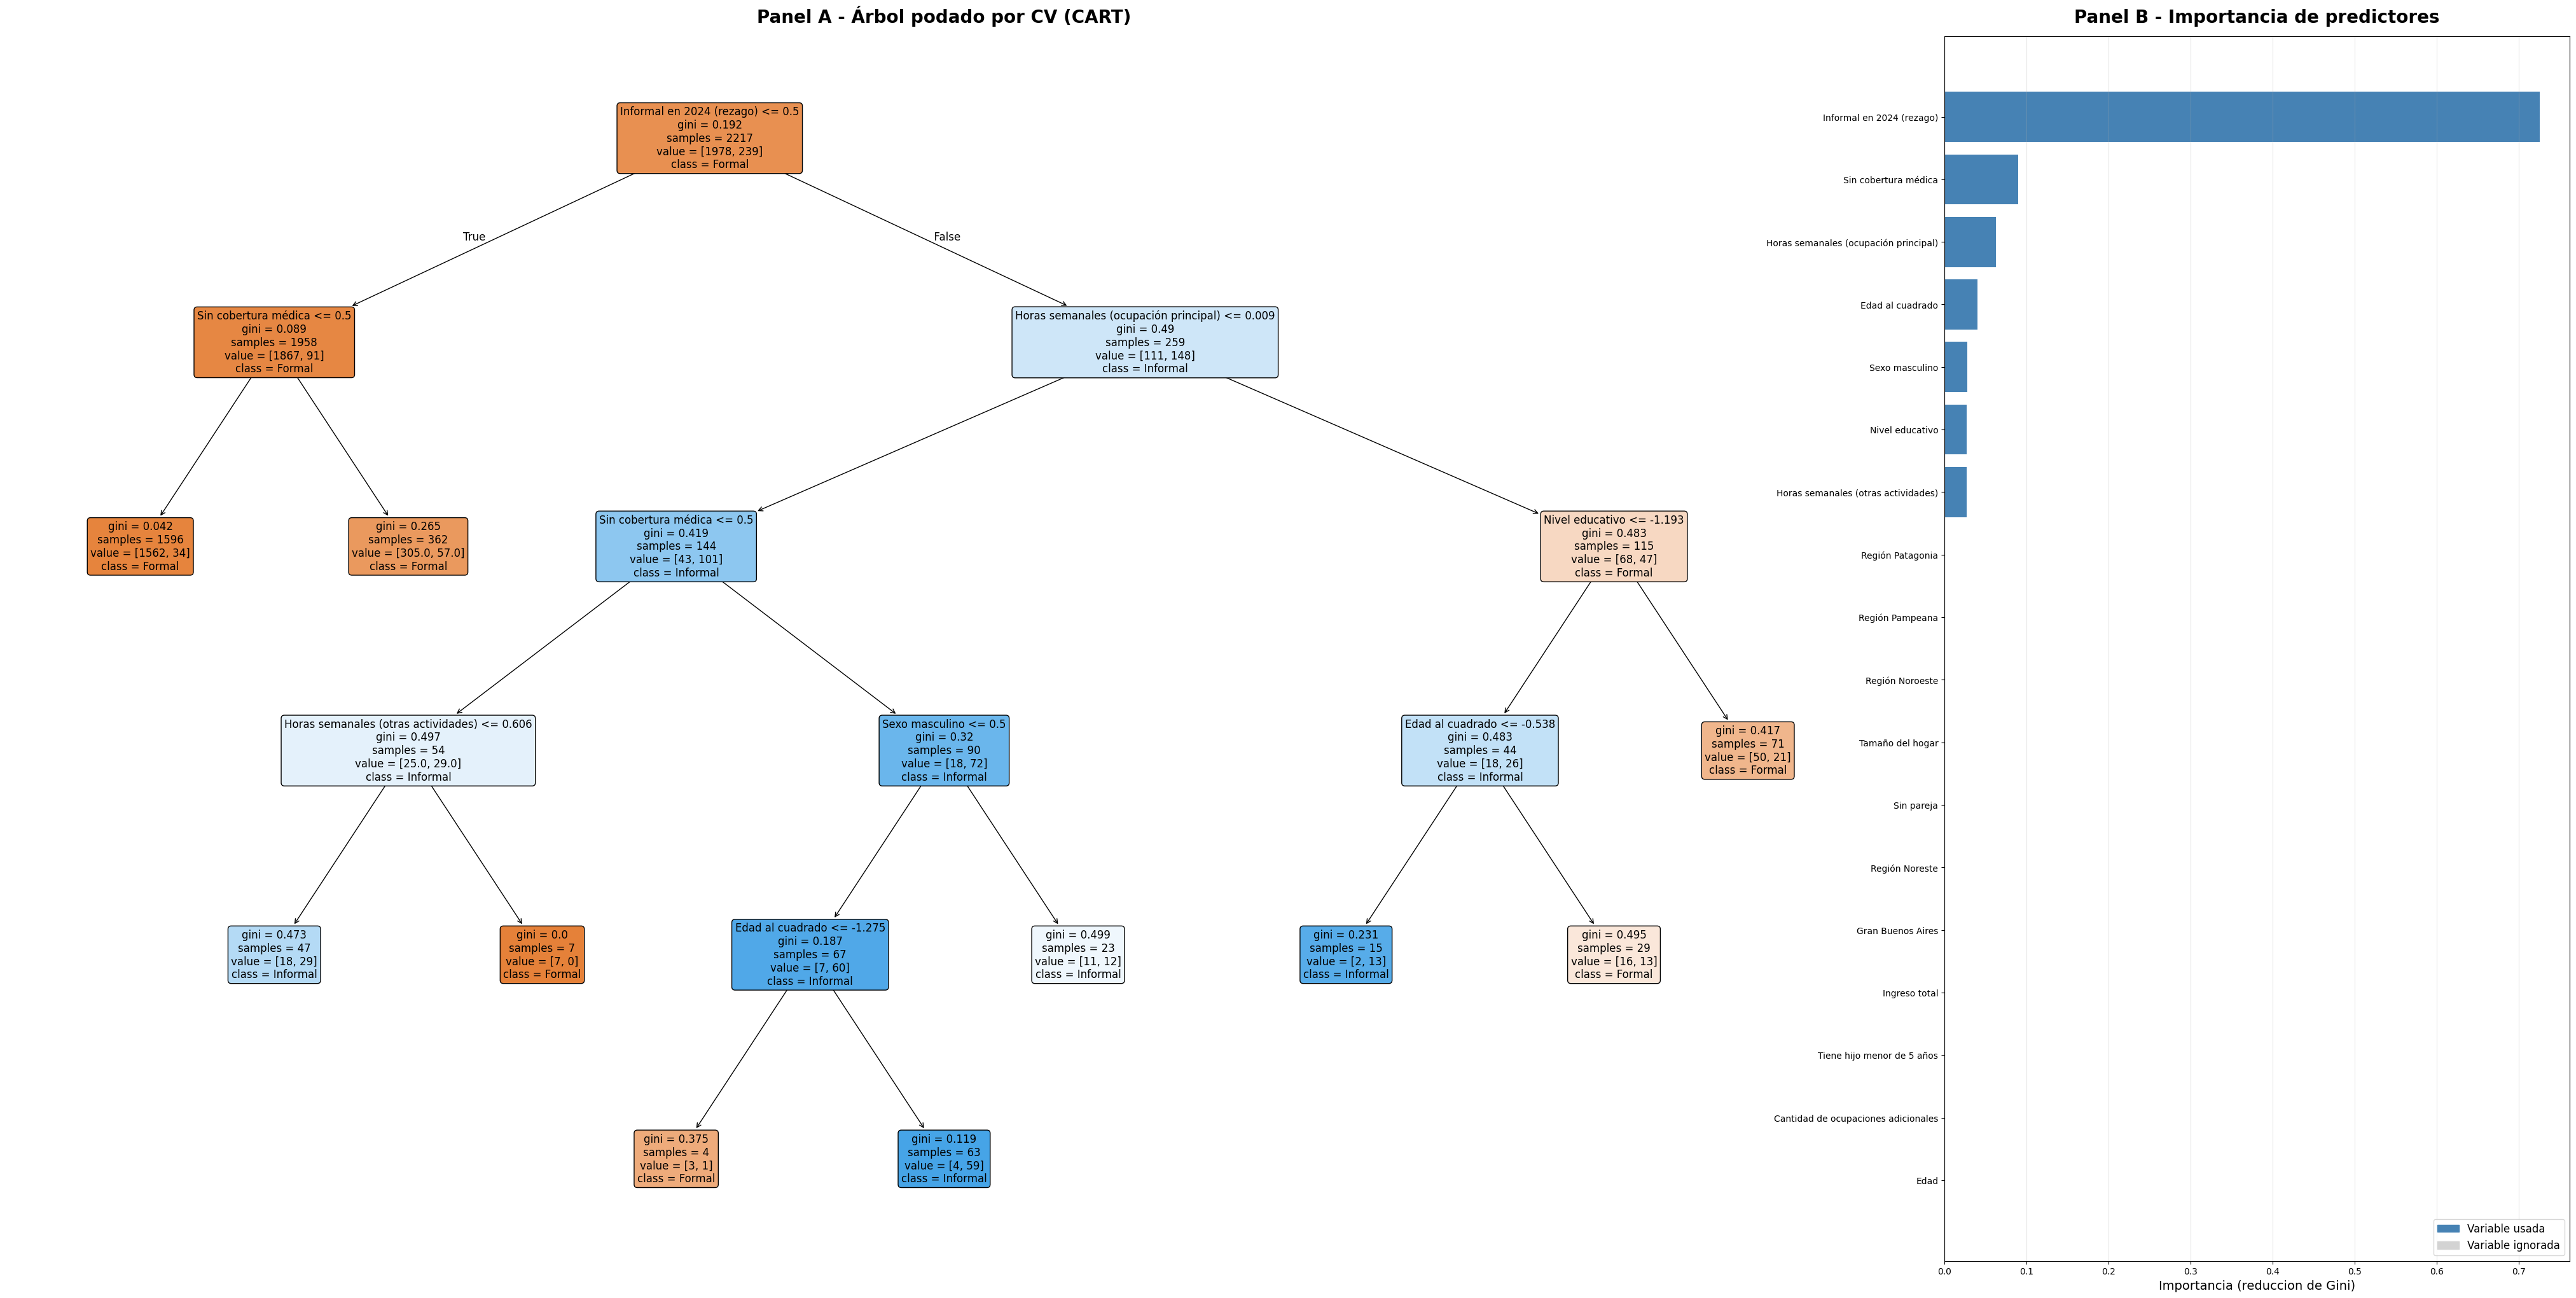

In [24]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Panel unificado con etiquetas legibles y tamanos aumentados:
fig = plt.figure(figsize = (52, 25))
gs  = fig.add_gridspec(1, 2, width_ratios=[3, 1], wspace=0.05)

# --- Panel A: Arbol podado ---
ax_tree = fig.add_subplot(gs[0])

# Usamos las etiquetas legibles del diccionario definido previamente
feature_names_legibles = [etiquetas.get(col, col) for col in X_train.columns]

plot_tree(decision_tree,
          impurity      = True,
          feature_names = feature_names_legibles,
          class_names   = ['Formal', 'Informal'],
          rounded       = True,
          filled        = True,
          ax            = ax_tree,
          fontsize      = 12) # Fuente aumentada para legibilidad

ax_tree.set_title('Panel A - Árbol podado por CV (CART)',
                  fontsize=20, fontweight='bold', pad = 15)

# --- Panel B: Importancia de predictores ---
ax_imp = fig.add_subplot(gs[1])

# Usamos la serie 'importancias' ya calculada
colores = ['steelblue' if v > 0 else 'lightgrey' for v in importancias]
ax_imp.barh(importancias.index, importancias.values, color = colores)
ax_imp.axvline(x = 0, color = 'black', linewidth = 0.8)
ax_imp.set_xlabel('Importancia (reduccion de Gini)', fontsize = 14)
ax_imp.set_title('Panel B - Importancia de predictores',
                 fontsize = 20, fontweight = 'bold', pad = 15)
ax_imp.grid(axis = 'x', alpha = 0.3)

leyenda = [Patch(color = 'steelblue', label = 'Variable usada'),
           Patch(color = 'lightgrey',  label = 'Variable ignorada')]
ax_imp.legend(handles = leyenda, loc = 'lower right', fontsize = 12)

fig.savefig('B2_arbol_e_importancia.pdf', bbox_inches = 'tight')
plt.show()

# Parte C: Comparación modelos

## C.1. Desempeño de los modelos predictivos de la informalidad en Argentina:

Observaciones evaluadas (test): 739
Tasa de informalidad observada en test: 0.1083
Probabilidad predicha media - Sin penalidad: 0.1134
Probabilidad predicha media - LASSO: 0.1134
Probabilidad predicha media - Ridge: 0.1134
Probabilidad predicha media - Árbol de decisión: 0.112
--- Matriz de confusion: Sin penalidad (test, umbral 0.5) ---
                Pred: Formal  Pred: Informal
Real: Formal             633              26
Real: Informal            43              37
VN = 633 | FP = 26 | FN = 43 | VP = 37
--- Matriz de confusion: LASSO (test, umbral 0.5) ---
                Pred: Formal  Pred: Informal
Real: Formal             632              27
Real: Informal            43              37
VN = 632 | FP = 27 | FN = 43 | VP = 37
--- Matriz de confusion: Ridge (test, umbral 0.5) ---
                Pred: Formal  Pred: Informal
Real: Formal             632              27
Real: Informal            43              37
VN = 632 | FP = 27 | FN = 43 | VP = 37
--- Matriz de confusion: Árbol

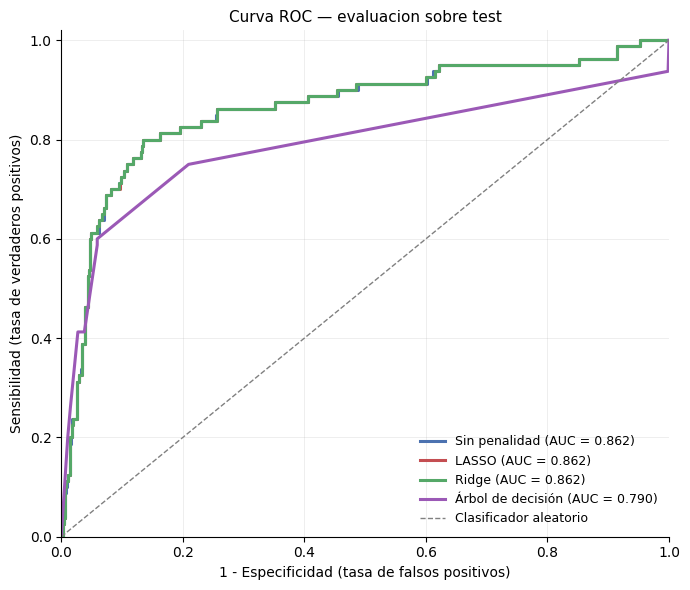

In [25]:
#%% C.1 (adelanto). Evaluacion sobre test de los tres modelos de la Parte A:

"""
Se evaluan sobre X_test / y_test los tres modelos entrenados SOLO con
train en A.3 (modelo_sin_penalidad, modelo_l1_final, modelo_l2_final),
y ahora se suma el árbol de decisión.
Estos datos de test nunca fueron usados ni para elegir hiperparámetros
ni para estimar estos coeficientes especificos, por lo que las metricas
que salen aca son una medida honesta de que tan bien generaliza cada
modelo.
"""

from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score
)
import matplotlib.pyplot as plt

# C.1.1. Probabilidades predichas sobre test, para cada modelo:
"""
'.predict_proba(X_test)[:, 1]' devuelve la probabilidad de la clase 1
(informal), usando los coeficientes ya fijados en train -- el modelo
NUNCA vio estas observaciones de test durante su ajuste.
"""

prob_sin_penalidad = modelo_sin_penalidad.predict_proba(X_test)[:, 1]
prob_lasso         = modelo_l1_final.predict_proba(X_test)[:, 1]
prob_ridge         = modelo_l2_final.predict_proba(X_test)[:, 1]
prob_arbol         = decision_tree.predict_proba(X_test)[:, 1]

print("Observaciones evaluadas (test):", len(y_test))
print("Tasa de informalidad observada en test:", round(y_test.mean(), 4))
print("Probabilidad predicha media - Sin penalidad:", round(prob_sin_penalidad.mean(), 4))
print("Probabilidad predicha media - LASSO:", round(prob_lasso.mean(), 4))
print("Probabilidad predicha media - Ridge:", round(prob_ridge.mean(), 4))
print("Probabilidad predicha media - Árbol de decisión:", round(prob_arbol.mean(), 4))

# C.1.2. Clasificacion con umbral p > 0.5:
UMBRAL = 0.5

pred_sin_penalidad = (prob_sin_penalidad > UMBRAL).astype(int)
pred_lasso         = (prob_lasso         > UMBRAL).astype(int)
pred_ridge         = (prob_ridge         > UMBRAL).astype(int)
pred_arbol         = (prob_arbol         > UMBRAL).astype(int)

# C.1.3. Funcion auxiliar para mostrar la matriz de confusion:
def mostrar_confusion(y_real, y_pred, nombre):
    cm = confusion_matrix(y_real, y_pred, labels = [0, 1])
    tn, fp, fn, tp = cm.ravel()

    tabla = pd.DataFrame(
        cm,
        index   = ['Real: Formal', 'Real: Informal'],
        columns = ['Pred: Formal', 'Pred: Informal']
    )

    print(f"--- Matriz de confusion: {nombre} (test, umbral {UMBRAL}) ---")
    print(tabla)
    print(f"VN = {tn} | FP = {fp} | FN = {fn} | VP = {tp}")
    return cm, tabla

cm_sin_penalidad, _ = mostrar_confusion(y_test, pred_sin_penalidad, 'Sin penalidad')
cm_lasso,         _ = mostrar_confusion(y_test, pred_lasso,         'LASSO')
cm_ridge,         _ = mostrar_confusion(y_test, pred_ridge,         'Ridge')
cm_arbol,         _ = mostrar_confusion(y_test, pred_arbol,         'Árbol de decisión')

# C.1.4. Metricas de desempeno, comparables entre los modelos:
def metricas_modelo(y_real, y_pred, y_prob, nombre):
    cm = confusion_matrix(y_real, y_pred, labels = [0, 1])
    tn, fp, fn, tp = cm.ravel()
    especificidad = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return {
        'Modelo':                nombre,
        'Exactitud':             accuracy_score(y_real, y_pred),
        'Sensibilidad (recall)': recall_score(y_real, y_pred, zero_division = 0),
        'Especificidad':         especificidad,
        'Precision':             precision_score(y_real, y_pred, zero_division = 0),
        'F1':                    f1_score(y_real, y_pred, zero_division = 0),
        'Exactitud balanceada':  balanced_accuracy_score(y_real, y_pred),
        'AUC-ROC':               roc_auc_score(y_real, y_prob),
        'VN': tn, 'FP': fp, 'FN': fn, 'VP': tp
    }

tabla_metricas_final = pd.DataFrame([
    metricas_modelo(y_test, pred_sin_penalidad, prob_sin_penalidad, 'Sin penalidad'),
    metricas_modelo(y_test, pred_lasso,         prob_lasso,         'LASSO'),
    metricas_modelo(y_test, pred_ridge,         prob_ridge,         'Ridge'),
    metricas_modelo(y_test, pred_arbol,         prob_arbol,         'Árbol de decisión'),
]).set_index('Modelo')

print("Metricas de desempeño sobre TEST:")
print(tabla_metricas_final.round(4).to_string())

tabla_metricas_final.to_excel(
    "C1_metricas_finales.xlsx",
    sheet_name   = "Metricas",
    float_format = "%.4f"
)

# C.1.5. Curvas ROC de los modelos:
fpr_sp, tpr_sp, _ = roc_curve(y_test, prob_sin_penalidad)
fpr_l1, tpr_l1, _ = roc_curve(y_test, prob_lasso)
fpr_l2, tpr_l2, _ = roc_curve(y_test, prob_ridge)
fpr_ar, tpr_ar, _ = roc_curve(y_test, prob_arbol)

auc_sp = roc_auc_score(y_test, prob_sin_penalidad)
auc_l1 = roc_auc_score(y_test, prob_lasso)
auc_l2 = roc_auc_score(y_test, prob_ridge)
auc_ar = roc_auc_score(y_test, prob_arbol)

fig, ax = plt.subplots(figsize = (7, 6))
ax.plot(fpr_sp, tpr_sp, color = '#4C72B0', linewidth = 2.2,
        label = f'Sin penalidad (AUC = {auc_sp:.3f})')
ax.plot(fpr_l1, tpr_l1, color = '#C44E52', linewidth = 2.2,
        label = f'LASSO (AUC = {auc_l1:.3f})')
ax.plot(fpr_l2, tpr_l2, color = '#55A868', linewidth = 2.2,
        label = f'Ridge (AUC = {auc_l2:.3f})')
ax.plot(fpr_ar, tpr_ar, color = '#9b59b6', linewidth = 2.2,
        label = f'Árbol de decisión (AUC = {auc_ar:.3f})')
ax.plot([0, 1], [0, 1], color = 'grey', linewidth = 1,
        linestyle = '--', label = 'Clasificador aleatorio')

ax.set_xlabel('1 - Especificidad (tasa de falsos positivos)')
ax.set_ylabel('Sensibilidad (tasa de verdaderos positivos)')
ax.set_title('Curva ROC — evaluacion sobre test', fontsize = 11)
ax.legend(frameon = False, fontsize = 9, loc = 'lower right')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha = 0.25, linewidth = 0.6)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig("C1_roc_final.png", dpi = 300, bbox_inches = 'tight')
plt.show()


## C.2. Comparativa de las variables desestimadas en el árbol de decisión y las variables regularizadas a cero en el modelo LASSO:

In [26]:
import pandas as pd
import numpy as np

# 1. Definir un umbral de tolerancia para considerar una variable como 'descartada'
# LASSO puede devolver valores como 1e-12 que son virtualmente cero.
tolerancia = 1e-5

# 2. Identificar variables descartadas por el Árbol (Importancia = 0)
importancias_orig = pd.Series(decision_tree.feature_importances_, index = X_train.columns)
vars_descartadas_arbol = importancias_orig[importancias_orig == 0].index.tolist()

# 3. Identificar variables descartadas por LASSO usando la tolerancia
# coef_l1_final_full contiene los coeficientes finales del modelo LASSO
vars_descartadas_lasso = coef_l1_final_full[coef_l1_final_full.abs() < tolerancia].index.tolist()

# 4. Construir la tabla comparativa
todas_las_variables = X_train.columns.tolist()
comparativa = []

for var in todas_las_variables:
    label = etiquetas.get(var, var)
    comparativa.append({
        'Variable': label,
        'Nombre técnico': var,
        'Descartada por Árbol': 'SÍ' if var in vars_descartadas_arbol else 'NO (Usada)',
        'Descartada por LASSO': 'SÍ' if var in vars_descartadas_lasso else 'NO (Usada)',
        'Valor Coef. LASSO': coef_l1_final_full[var]
    })

df_comparativo = pd.DataFrame(comparativa)

# Mostrar resumen y tabla
print(f"Total variables en el modelo: {len(todas_las_variables)}")
print(f"Variables descartadas por Árbol (Imp = 0): {len(vars_descartadas_arbol)}")
print(f"Variables descartadas por LASSO (Abs < {tolerancia}): {len(vars_descartadas_lasso)}")

display(df_comparativo.sort_values(by='Descartada por LASSO', ascending=False))

Total variables en el modelo: 18
Variables descartadas por Árbol (Imp = 0): 11
Variables descartadas por LASSO (Abs < 1e-05): 0


,Variable,Nombre técnico,Descartada por Árbol,Descartada por LASSO,Valor Coef. LASSO
0,Edad,edad,SÍ,NO (Usada),-1.549567
1,Cantidad de ocupaciones adicionales,cant_ocupaciones_ad,SÍ,NO (Usada),0.306780
16,Región Patagonia,region_cat_Patagonia,SÍ,NO (Usada),-0.417730
15,Región Pampeana,region_cat_Pampeana,SÍ,NO (Usada),0.007429
14,Región Noroeste,region_cat_Noroeste,SÍ,NO (Usada),-0.244993
13,Región Noreste,region_cat_Noreste,SÍ,NO (Usada),-0.593048
12,Gran Buenos Aires,region_cat_Gran Buenos Aires,SÍ,NO (Usada),-0.059856
11,Sin cobertura médica,cobertura_med_No cobertura,NO (Usada),NO (Usada),1.403950
10,Sin pareja,estado_civil_Sin pareja,SÍ,NO (Usada),0.452915
9,Sexo masculino,sexo_Masculino,NO (Usada),NO (Usada),-0.543544
